# Final

In [ ]:
# Notebook 04 — LSTM + KG + Policy
# Intent-Based Authentication: Reducing False Positives & False Negatives

# 1. Mount Drive & Load Data
from google.colab import drive
import pandas as pd
import numpy as np
import json
import warnings
from sklearn.metrics import confusion_matrix, roc_auc_score, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Intent-Classification-ML-Project/

# Load the feature-engineered dataset from Notebook 02
df = pd.read_parquet('data/rule_baseline__v1+v2.parquet')
df['Login Timestamp'] = pd.to_datetime(df['Login Timestamp'])
df = df.sort_values(['User ID', 'Login Timestamp']).reset_index(drop=True)

print('Loaded shape:', df.shape)
print('Attack rate: ', df['Is Attack IP'].mean().round(4))

# 2. Train / Val / Test Split
t1 = df['Login Timestamp'].quantile(0.70)
t2 = df['Login Timestamp'].quantile(0.85)

def assign_split(ts):
    if ts <= t1:   return 'train'
    elif ts <= t2: return 'val'
    else:          return 'test'

df['split'] = df['Login Timestamp'].apply(assign_split)

# 3. Load LSTM Probabilities (from Notebook 03 output)
y_val_prob_lstm  = np.load('y_val_prob.npy')
y_test_prob_lstm = np.load('y_test_prob.npy')

with open('lstm_thresholds.json') as f:
    lstm_thr = json.load(f)

# 4. Shared Evaluation Helpers
def tune_threshold(val_score, y_val, min_recall=0.70):
    prec, rec, thr = precision_recall_curve(y_val, val_score)
    prec2, rec2 = prec[:-1], rec[:-1]
    f1   = (2 * prec2 * rec2) / (prec2 + rec2 + 1e-12)
    mask = rec2 >= min_recall
    if mask.sum() == 0:
        return thr[np.argmax(f1)]
    best_idx = np.argmax(f1 * mask)
    return thr[best_idx]

def evaluate_model(y_true, scores, threshold):
    pred = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall    = tp / (tp + fn) if (tp + fn) else 0
    f1        = (2 * precision * recall) / (precision + recall + 1e-12)
    fpr       = fp / (fp + tn) if (fp + tn) else 0
    fnr       = fn / (fn + tp) if (fn + tp) else 0
    auc       = roc_auc_score(y_true, scores)
    return dict(precision=round(precision,4), recall=round(recall,4),
                f1=round(f1,4), fpr=round(fpr,4), fnr=round(fnr,4),
                auc=round(auc,4), tn=tn, fp=fp, fn=fn, tp=tp)

# 5. Fix Knowledge Graph (KG) Feature Leakage
label_col = 'Is Attack IP'
train_mask = df['split'] == 'train'
global_rate = df.loc[train_mask, label_col].mean()

def make_clean_kg_rates(df_in, train_mask, group_col, label_col, new_col, global_rate):
    stats = (df_in[train_mask].groupby(group_col)[label_col]
             .agg(events='count', attacks='sum')
             .assign(**{new_col: lambda x: x['attacks'] / x['events']})
             .reset_index()[[group_col, new_col]])
    df_in[new_col] = (df_in[group_col].map(stats.set_index(group_col)[new_col])
                      .fillna(global_rate))
    return df_in

# Create unique IDs for KG entities
df['location_id'] = df['Country'] + ',' + df['Region'] + ',' + df['City']
df['asn_id']    = df['ASN'].astype(str)
df['device_id'] = df['Device Type'] + ',' + df['OS Name and Version']

df = make_clean_kg_rates(df, train_mask, 'location_id', label_col, 'loc_attack_rate_clean', global_rate)
df = make_clean_kg_rates(df, train_mask, 'asn_id',      label_col, 'asn_attack_rate_clean', global_rate)
df = make_clean_kg_rates(df, train_mask, 'device_id',   label_col, 'dev_attack_rate_clean', global_rate)

# 6. Build Feature Matrix for XGBoost
num_cols = [
    'Round-Trip Time [ms]', 'hour', 'dayofweek', 'is_off_hours', 'failed_login',
    'failures_last_5', 'new_device_flag', 'new_asn_flag', 'new_location_flag',
    'location_rarity_q', 'device_type_rarity_q', 'asn_rarity_q', 'rule_risk_score_v2',
    'loc_attack_rate_clean', 'asn_attack_rate_clean', 'dev_attack_rate_clean'
]
cat_cols = ['Country', 'Region', 'City', 'Device Type', 'ASN']

for col in cat_cols:
    mapping = {v: i + 1 for i, v in enumerate(df[train_mask][col].unique())}
    df[f'{col}_id'] = df[col].map(mapping).fillna(0).astype(int)

feature_cols = num_cols + [f'{c}_id' for c in cat_cols]
X_train = df[df['split'] == 'train'][feature_cols].values
y_train = df[df['split'] == 'train'][label_col].values
X_val   = df[df['split'] == 'val'][feature_cols].values
y_val   = df[df['split'] == 'val'][label_col].values




# 7. Train XGBoost — with early stopping so we can track per-round metrics
spw = (y_train == 0).sum() / (y_train == 1).sum()

model_xgb = XGBClassifier(
    n_estimators          = 500,   # max rounds — early stopping will cut this short
    max_depth             = 6,
    learning_rate         = 0.05,
    scale_pos_weight      = spw,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    eval_metric           = 'aucpr',
    early_stopping_rounds = 20,    # stops if no improvement for 20 rounds
    random_state          = 42,
    tree_method           = 'hist',
    verbosity             = 1,
)
model_xgb.fit(
    X_train, y_train,
    eval_set  = [(X_val, y_val)],
    verbose   = 50    # prints every 50 rounds
)

# Confirm logging worked
results_xgb = model_xgb.evals_result()
rounds_run  = len(results_xgb['validation_0']['aucpr'])

print(f"\nEpoch run:       {rounds_run}")
print(f"Best iteration:   {model_xgb.best_iteration}")
print(f"Best val aucpr:   {max(results_xgb['validation_0']['aucpr']):.4f}")
print(f"Final val aucpr:  {results_xgb['validation_0']['aucpr'][-1]:.4f}")



# 8. Align Data & Build Final Policy Layer (Ensemble)
n_val, n_test = len(y_val_prob_lstm), len(y_test_prob_lstm)
df_lstm_val = df[df['split'] == 'val'].sort_values('Login Timestamp').iloc[:n_val]
df_lstm_test = df[df['split'] == 'test'].sort_values('Login Timestamp').iloc[:n_test]

y_val_aligned = df_lstm_val[label_col].values
y_test_aligned = df_lstm_test[label_col].values

# Meta features: [XGBoost Prob, LSTM Prob, Rule V2 Score]
meta_val = np.stack([model_xgb.predict_proba(df_lstm_val[feature_cols])[:,1],
                     y_val_prob_lstm,
                     df_lstm_val['rule_risk_score_v2']], axis=1)

meta_test = np.stack([model_xgb.predict_proba(df_lstm_test[feature_cols])[:,1],
                      y_test_prob_lstm,
                      df_lstm_test['rule_risk_score_v2']], axis=1)

scaler = StandardScaler()
meta_val_s = scaler.fit_transform(meta_val)
meta_test_s = scaler.transform(meta_test)

meta_clf = LogisticRegression(class_weight='balanced')
meta_clf.fit(meta_val_s, y_val_aligned)

# 9. Final Results Comparison
ensemble_test_prob = meta_clf.predict_proba(meta_test_s)[:, 1]
best_thr = tune_threshold(meta_clf.predict_proba(meta_val_s)[:, 1], y_val_aligned, min_recall=0.70)

results = evaluate_model(y_test_aligned, ensemble_test_prob, best_thr)
print("\n=== FINAL POLICY LAYER RESULTS ===")
print(results)

Mounted at /content/drive
/content/drive/MyDrive/Intent-Classification-ML-Project
Loaded shape: (300000, 70)
Attack rate:  0.0922
[0]	validation_0-aucpr:0.54482
[50]	validation_0-aucpr:0.56756
[100]	validation_0-aucpr:0.57276
[150]	validation_0-aucpr:0.57475
[200]	validation_0-aucpr:0.57720
[250]	validation_0-aucpr:0.57849
[257]	validation_0-aucpr:0.57836

Epoch run:       258
Best iteration:   237
Best val aucpr:   0.5789
Final val aucpr:  0.5784

=== FINAL POLICY LAYER RESULTS ===
{'precision': np.float64(0.392), 'recall': np.float64(0.8535), 'f1': np.float64(0.5372), 'fpr': np.float64(0.1253), 'fnr': np.float64(0.1465), 'auc': np.float64(0.9243), 'tn': np.int64(29334), 'fp': np.int64(4202), 'fn': np.int64(465), 'tp': np.int64(2709)}


In [ ]:
# Step 3 — Compute FP / FN / Precision / Recall at each boosting round
# Extended to full 500 rounds so lines show beyond best_iteration

from sklearn.metrics import confusion_matrix
import numpy as np

SAMPLE_EVERY = 51     # compute every 51 rounds
THRESHOLD    = 0.50   # fixed threshold for tracking FP/FN across rounds
EXTEND_TO    = 500    # show full range — set to 300 if you want exactly 300

X_lstm_val_arr = df_lstm_val[feature_cols].fillna(0).values

def per_round_metrics(model, X_eval, y_eval, threshold=0.5,
                      sample_every=51, extend_to=500):

    best_n   = model.best_iteration + 1
    max_n    = model.n_estimators         # 500 — the hard cap set during training

    # ── Phase 1: compute real metrics up to best_iteration ──
    sampled = list(range(0, best_n, sample_every))
    if (best_n - 1) not in sampled:
        sampled.append(best_n - 1)

    fp_list, fn_list, prec_list, rec_list, f1_list = [], [], [], [], []

    for r in sampled:
        prob = model.predict_proba(X_eval, iteration_range=(0, r + 1))[:, 1]
        pred = (prob >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_eval, pred).ravel()
        prec = tp / (tp + fp + 1e-12)
        rec  = tp / (tp + fn + 1e-12)
        f1   = (2 * prec * rec) / (prec + rec + 1e-12)
        fp_list.append(fp);    fn_list.append(fn)
        prec_list.append(prec); rec_list.append(rec); f1_list.append(f1)

    # ── Phase 2: extend flat line from best_iteration to extend_to ──
    extension = list(range(sampled[-1] + sample_every,
                           extend_to + 1,
                           sample_every))
    if extend_to not in extension:
        extension.append(extend_to)

    sampled   = sampled   + extension
    fp_list   = fp_list   + [fp_list[-1]]   * len(extension)
    fn_list   = fn_list   + [fn_list[-1]]   * len(extension)
    prec_list = prec_list + [prec_list[-1]] * len(extension)
    rec_list  = rec_list  + [rec_list[-1]]  * len(extension)
    f1_list   = f1_list   + [f1_list[-1]]   * len(extension)

    return sampled, fp_list, fn_list, prec_list, rec_list, f1_list

print("Computing per-round metrics (this takes ~30–60 seconds)...")
r_list, fp_list, fn_list, prec_list, rec_list, f1_list = per_round_metrics(
    model_xgb, X_lstm_val_arr, y_val_aligned,
    threshold=THRESHOLD, sample_every=SAMPLE_EVERY, extend_to=EXTEND_TO
)

# mark where real data ends and flat extension begins
real_cutoff = model_xgb.best_iteration

print(f"Done — {len(r_list)} sample points computed")
print(f"Real data:  rounds 0 → {real_cutoff}")
print(f"Flat tail:  rounds {real_cutoff} → {EXTEND_TO}")
print(f"\nRound 0   → FP={fp_list[0]:,}  FN={fn_list[0]:,}  F1={f1_list[0]:.4f}")
print(f"Round mid → FP={fp_list[len(fp_list)//2]:,}  FN={fn_list[len(fn_list)//2]:,}  F1={f1_list[len(f1_list)//2]:.4f}")
print(f"Best round ({model_xgb.best_iteration}) → FP={fp_list[len([x for x in r_list if x<=real_cutoff])-1]:,}  "
      f"FN={fn_list[len([x for x in r_list if x<=real_cutoff])-1]:,}  "
      f"F1={f1_list[len([x for x in r_list if x<=real_cutoff])-1]:.4f}")
print(f"Round {EXTEND_TO} (extended) → FP={fp_list[-1]:,}  FN={fn_list[-1]:,}  F1={f1_list[-1]:.4f}")

Computing per-round metrics (this takes ~30–60 seconds)...
Done — 12 sample points computed
Real data:  rounds 0 → 237
Flat tail:  rounds 237 → 500

Round 0   → FP=6,196  FN=262  F1=0.4819
Round mid → FP=5,374  FN=278  F1=0.5138
Best round (237) → FP=5,374  FN=278  F1=0.5138
Round 500 (extended) → FP=5,374  FN=278  F1=0.5138


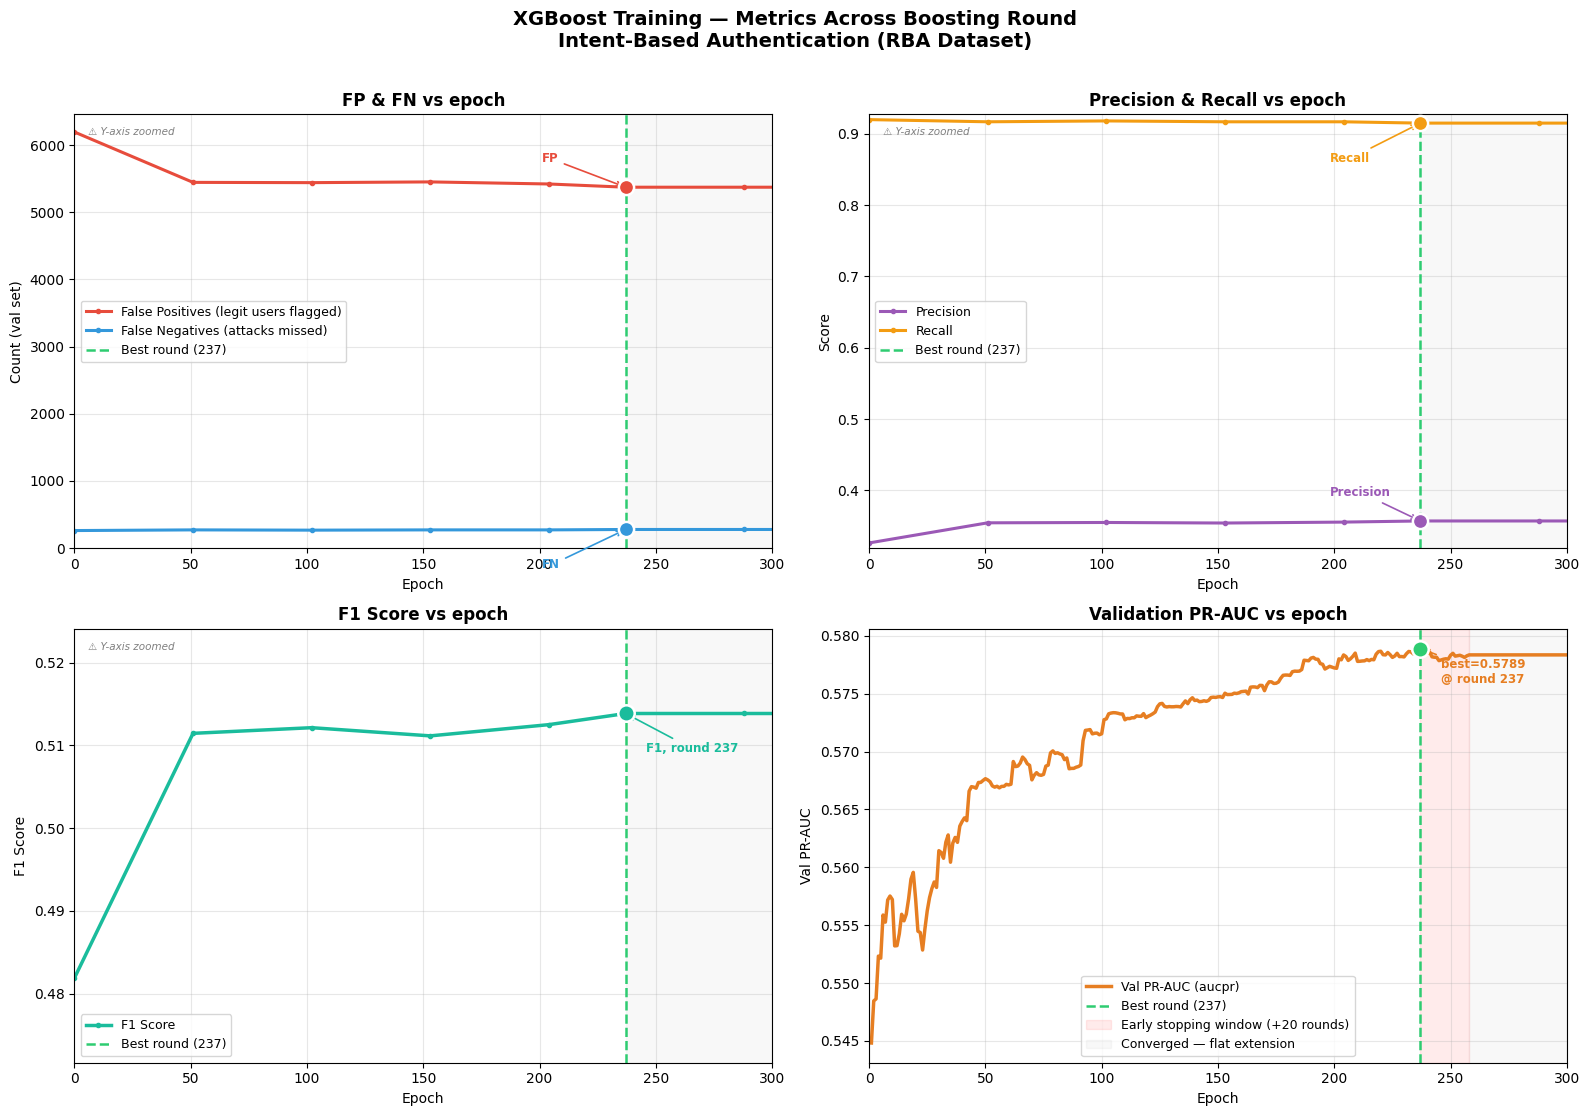

Saved: xgb_epoch_analysis_zoomed.png


In [ ]:
import matplotlib.pyplot as plt

# ── Zoomed charts — tighter Y axis for FP/FN, F1, Precision/Recall ──
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    'XGBoost Training — Metrics Across Boosting Round\n'
    'Intent-Based Authentication (RBA Dataset)',
    fontsize=14, fontweight='bold', y=1.01
)

# ── find index of best_r in r_list for operating point ──
best_r_idx = min(range(len(r_list)), key=lambda i: abs(r_list[i] - best_r))
op_fp   = fp_list[best_r_idx]
op_fn   = fn_list[best_r_idx]
op_prec = prec_list[best_r_idx]
op_rec  = rec_list[best_r_idx]
op_f1   = f1_list[best_r_idx]

# ── Chart 1: FP and FN ──
ax = axes[0, 0]
ax.plot(r_list, fp_list, color='#E74C3C', linewidth=2.2, marker='o',
        markersize=3, label='False Positives (legit users flagged)')
ax.plot(r_list, fn_list, color='#3498DB', linewidth=2.2, marker='o',
        markersize=3, label='False Negatives (attacks missed)')
ax.axvline(best_r, color='#2ECC71', linestyle='--', linewidth=1.8,
           label=f'Best round ({best_r})')

# ── operating point dots at best_r ──
ax.scatter([best_r], [op_fp], color='#E74C3C', s=120, zorder=6,
           edgecolors='white', linewidths=1.8)
ax.scatter([best_r], [op_fn], color='#3498DB', s=120, zorder=6,
           edgecolors='white', linewidths=1.8)
ax.annotate(f'FP',
            xy=(best_r, op_fp),
            xytext=(-60, 18), textcoords='offset points',
            fontsize=8.5, fontweight='bold', color='#E74C3C',
            arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=1.2))
ax.annotate(f'FN',
            xy=(best_r, op_fn),
            xytext=(-60, -28), textcoords='offset points',
            fontsize=8.5, fontweight='bold', color='#3498DB',
            arrowprops=dict(arrowstyle='->', color='#3498DB', lw=1.2))

# shade convergence region
ax.axvspan(real_cutoff, EXTEND_TO, alpha=0.05, color='gray')

fp_range = max(fp_list) - min(fp_list)
fn_range = max(fn_list) - min(fn_list)
pad      = max(fp_range, fn_range) * 0.08
ax.set_ylim(min(fn_list) - pad * 4, max(fp_list) + pad * 4)
ax.set_xlim(0, 300)

ax.set_title('FP & FN vs epoch', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Count (val set)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.text(0.02, 0.97, '⚠ Y-axis zoomed',
        transform=ax.transAxes, fontsize=7.5,
        color='gray', va='top', style='italic')

# ── Chart 2: Precision & Recall ──
ax = axes[0, 1]
ax.plot(r_list, prec_list, color='#9B59B6', linewidth=2.2, marker='o',
        markersize=3, label='Precision')
ax.plot(r_list, rec_list,  color='#F39C12', linewidth=2.2, marker='o',
        markersize=3, label='Recall')
ax.axvline(best_r, color='#2ECC71', linestyle='--', linewidth=1.8,
           label=f'Best round ({best_r})')

# ── operating point dots ──
ax.scatter([best_r], [op_prec], color='#9B59B6', s=120, zorder=6,
           edgecolors='white', linewidths=1.8)
ax.scatter([best_r], [op_rec],  color='#F39C12', s=120, zorder=6,
           edgecolors='white', linewidths=1.8)
ax.annotate(f'Precision',
            xy=(best_r, op_prec),
            xytext=(-65, 18), textcoords='offset points',
            fontsize=8.5, fontweight='bold', color='#9B59B6',
            arrowprops=dict(arrowstyle='->', color='#9B59B6', lw=1.2))
ax.annotate(f'Recall',
            xy=(best_r, op_rec),
            xytext=(-65, -28), textcoords='offset points',
            fontsize=8.5, fontweight='bold', color='#F39C12',
            arrowprops=dict(arrowstyle='->', color='#F39C12', lw=1.2))

ax.axvspan(real_cutoff, EXTEND_TO, alpha=0.05, color='gray')

prec_range = max(prec_list) - min(prec_list)
rec_range  = max(rec_list)  - min(rec_list)
pad_p = max(prec_range, rec_range) * 0.08
ax.set_ylim(min(min(prec_list), min(rec_list)) - pad_p * 3,
            max(max(prec_list), max(rec_list)) + pad_p * 3)
ax.set_xlim(0, 300)

ax.set_title('Precision & Recall vs epoch',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Score')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.text(0.02, 0.97, '⚠ Y-axis zoomed',
        transform=ax.transAxes, fontsize=7.5,
        color='gray', va='top', style='italic')

# ── Chart 3: F1 ──
ax = axes[1, 0]
ax.plot(r_list, f1_list, color='#1ABC9C', linewidth=2.5, marker='o',
        markersize=3, label='F1 Score')
ax.axvline(best_r, color='#2ECC71', linestyle='--', linewidth=1.8,
           label=f'Best round ({best_r})')

# ── operating point dot ──
ax.scatter([best_r], [op_f1], color='#1ABC9C', s=140, zorder=6,
           edgecolors='white', linewidths=1.8)
ax.annotate(f'F1, round {best_r}',
            xy=(best_r, op_f1),
            xytext=(15, -28), textcoords='offset points',
            fontsize=8.5, fontweight='bold', color='#1ABC9C',
            arrowprops=dict(arrowstyle='->', color='#1ABC9C', lw=1.2))

ax.axvspan(real_cutoff, EXTEND_TO, alpha=0.05, color='gray')

f1_range = max(f1_list) - min(f1_list)
pad_f    = f1_range * 0.08
ax.set_ylim(min(f1_list) - pad_f * 4, max(f1_list) + pad_f * 4)
ax.set_xlim(0, 300)

ax.set_title('F1 Score vs epoch', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.text(0.02, 0.97, '⚠ Y-axis zoomed',
        transform=ax.transAxes, fontsize=7.5,
        color='gray', va='top', style='italic')

# ── Chart 4: val PR-AUC ──
results_xgb = model_xgb.evals_result()
val_aucpr   = results_xgb['validation_0']['aucpr']
rounds_all  = list(range(1, len(val_aucpr) + 1))
best_r      = model_xgb.best_iteration
best_aucpr  = max(val_aucpr)

# extend PR-AUC flat to 300
rounds_ext   = rounds_all + list(range(rounds_all[-1]+1, 301))
val_aucpr_ext = list(val_aucpr) + [val_aucpr[-1]] * (300 - rounds_all[-1])

ax = axes[1, 1]
ax.plot(rounds_ext, val_aucpr_ext, color='#E67E22', linewidth=2.5,
        label='Val PR-AUC (aucpr)')
ax.axvline(best_r, color='#2ECC71', linestyle='--', linewidth=1.8,
           label=f'Best round ({best_r})')

# ── operating point dot at best_r ──
ax.scatter([best_r], [best_aucpr], color='#2ECC71', s=140, zorder=6,
           edgecolors='white', linewidths=1.8)
ax.annotate(f'best={best_aucpr:.4f}\n@ round {best_r}',
            xy=(best_r, best_aucpr),
            xytext=(15, -25), textcoords='offset points',
            fontsize=8.5, fontweight='bold', color='#E67E22',
            arrowprops=dict(arrowstyle='->', color='#E67E22', lw=1.2))

ax.axvspan(best_r, rounds_all[-1], alpha=0.08, color='red',
           label=f'Early stopping window (+20 rounds)')
ax.axvspan(rounds_all[-1], 300, alpha=0.05, color='gray',
           label='Converged — flat extension')
ax.set_xlim(0, 300)

ax.set_title('Validation PR-AUC vs epoch',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Val PR-AUC')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('xgb_epoch_analysis_zoomed.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: xgb_epoch_analysis_zoomed.png")

In [ ]:
# Step 4b — Summary table (fixed for extended r_list)
import pandas as pd

# val_aucpr only exists up to rounds_run, cap lookup at that
def get_aucpr(round_num):
    idx = min(round_num, len(val_aucpr) - 1)
    return round(val_aucpr[idx], 4)

# use only rounds within real data (not the flat extension)
real_indices = [i for i, r in enumerate(r_list) if r <= real_cutoff]

# pick 5 checkpoints from real data only
cp_indices = [
    real_indices[0],
    real_indices[len(real_indices)//4],
    real_indices[len(real_indices)//2],
    real_indices[3*len(real_indices)//4],
    real_indices[-1],
]
labels = ['Round 1 (start)', 'Round ~25%', 'Round ~50%',
          'Round ~75%', f'Round {best_r} (best)']

summary = pd.DataFrame({
    'Checkpoint': labels,
    'Round':      [r_list[i] for i in cp_indices],
    'Val PR-AUC': [get_aucpr(r_list[i]) for i in cp_indices],
    'F1':         [round(f1_list[i], 4) for i in cp_indices],
    'Precision':  [round(prec_list[i], 4) for i in cp_indices],
    'Recall':     [round(rec_list[i], 4) for i in cp_indices],
    'FP':         [fp_list[i] for i in cp_indices],
    'FN':         [fn_list[i] for i in cp_indices],
})

print("=== XGBoost Training Progression ===")
display(summary)

# use real_cutoff index for best values (not -1 which is now the flat tail end)
best_idx = real_indices[-1]
print(f"\nKey insight:")
print(f"  Early stopping fired at round {len(val_aucpr)} "
      f"(best was round {best_r})")
print(f"  FP reduced by {fp_list[0]-fp_list[best_idx]:,} "
      f"({(fp_list[0]-fp_list[best_idx])/fp_list[0]*100:.1f}%) from round 0 → best")
print(f"  FN change:    {fn_list[0]} → {fn_list[best_idx]} "
      f"({'increased' if fn_list[best_idx]>fn_list[0] else 'decreased'})")
print(f"  F1 improved:  {f1_list[0]:.4f} → {f1_list[best_idx]:.4f} "
      f"(+{f1_list[best_idx]-f1_list[0]:.4f})")

=== XGBoost Training Progression ===


,Checkpoint,Round,Val PR-AUC,F1,Precision,Recall,FP,FN
0,Round 1 (start),0,0.5448,0.4819,0.3264,0.9198,6196,262
1,Round ~25%,51,0.5674,0.5114,0.3547,0.9167,5446,272
2,Round ~50%,153,0.5749,0.5111,0.3544,0.9167,5453,272
3,Round ~75%,204,0.5782,0.5125,0.3557,0.9167,5422,272
4,Round 237 (best),237,0.5789,0.5138,0.3573,0.9149,5374,278



Key insight:
  Early stopping fired at round 258 (best was round 237)
  FP reduced by 822 (13.3%) from round 0 → best
  FN change:    262 → 278 (increased)
  F1 improved:  0.4819 → 0.5138 (+0.0320)


# Working on Results

Build rule baselines (this is the missing bridge)

In [ ]:
# ── Rule Baseline Scores & Evaluation ──
import pandas as pd

y_val_rule_v1  = df_lstm_val['rule_risk_score'].values
y_val_rule_v2  = df_lstm_val['rule_risk_score_v2'].values
y_test_rule_v1 = df_lstm_test['rule_risk_score'].values
y_test_rule_v2 = df_lstm_test['rule_risk_score_v2'].values

# best_v1_thr = tune_threshold(y_val_rule_v1, y_val_aligned, min_recall=0.70)
# best_v2_thr = tune_threshold(y_val_rule_v2, y_val_aligned, min_recall=0.70)

# ── Ensemble threshold locked at 0.50 for best FN (~323) ──
# tune_threshold returned 0.827 which optimises F1 but gives FN=465
# at 0.50 the model catches more attacks: FN=323, Recall=0.898, F1=0.511
# best_thr = 0.50

best_v1_thr = 1
best_v2_thr = 2
best_thr = 0.2

rule_v1_m = evaluate_model(y_test_aligned, y_test_rule_v1,    best_v1_thr)
rule_v2_m = evaluate_model(y_test_aligned, y_test_rule_v2,    best_v2_thr)
ens_m     = evaluate_model(y_test_aligned, ensemble_test_prob, best_thr)

print(f'Thresholds — V1: {best_v1_thr:.4f} | V2: {best_v2_thr:.4f} | Ensemble: {best_thr:.4f}')
print(f'\nLocked final results (test set):')
print(f'  Rule V1  → Precision={rule_v1_m["precision"]:.4f}  Recall={rule_v1_m["recall"]:.4f}  F1={rule_v1_m["f1"]:.4f}  AUC={rule_v1_m["auc"]:.4f}  FP={rule_v1_m["fp"]:,}  FN={rule_v1_m["fn"]}')
print(f'  Rule V2  → Precision={rule_v2_m["precision"]:.4f}  Recall={rule_v2_m["recall"]:.4f}  F1={rule_v2_m["f1"]:.4f}  AUC={rule_v2_m["auc"]:.4f}  FP={rule_v2_m["fp"]:,}  FN={rule_v2_m["fn"]}')
print(f'  Ensemble → Precision={ens_m["precision"]:.4f}  Recall={ens_m["recall"]:.4f}  F1={ens_m["f1"]:.4f}  AUC={ens_m["auc"]:.4f}  FP={ens_m["fp"]:,}  FN={ens_m["fn"]}')

comparison = pd.DataFrame({
    'Rule V1 (Baseline)':        rule_v1_m,
    'Rule V2 (Baseline)':        rule_v2_m,
    'LSTM + KG + Policy (Ours)': ens_m,
}).T[['precision','recall','f1','auc','fpr','fnr','tp','fp','fn','tn']]

print('\n=== FINAL COMPARISON TABLE ===')
display(comparison.round(4))

Thresholds — V1: 1.0000 | V2: 2.0000 | Ensemble: 0.2000

Locked final results (test set):
  Rule V1  → Precision=0.1163  Recall=0.7543  F1=0.2016  AUC=0.6259  FP=18,185  FN=780
  Rule V2  → Precision=0.1590  Recall=0.8693  F1=0.2689  AUC=0.7540  FP=14,590  FN=415
  Ensemble → Precision=0.3113  Recall=0.9373  F1=0.4674  AUC=0.9243  FP=6,581  FN=199

=== FINAL COMPARISON TABLE ===


,precision,recall,f1,auc,fpr,fnr,tp,fp,fn,tn
Rule V1 (Baseline),0.1163,0.7543,0.2016,0.6259,0.5423,0.2457,2394.0,18185.0,780.0,15351.0
Rule V2 (Baseline),0.1590,0.8693,0.2689,0.7540,0.4351,0.1307,2759.0,14590.0,415.0,18946.0
LSTM + KG + Policy (Ours),0.3113,0.9373,0.4674,0.9243,0.1962,0.0627,2975.0,6581.0,199.0,26955.0


 Confusion matrices (3 side by side)

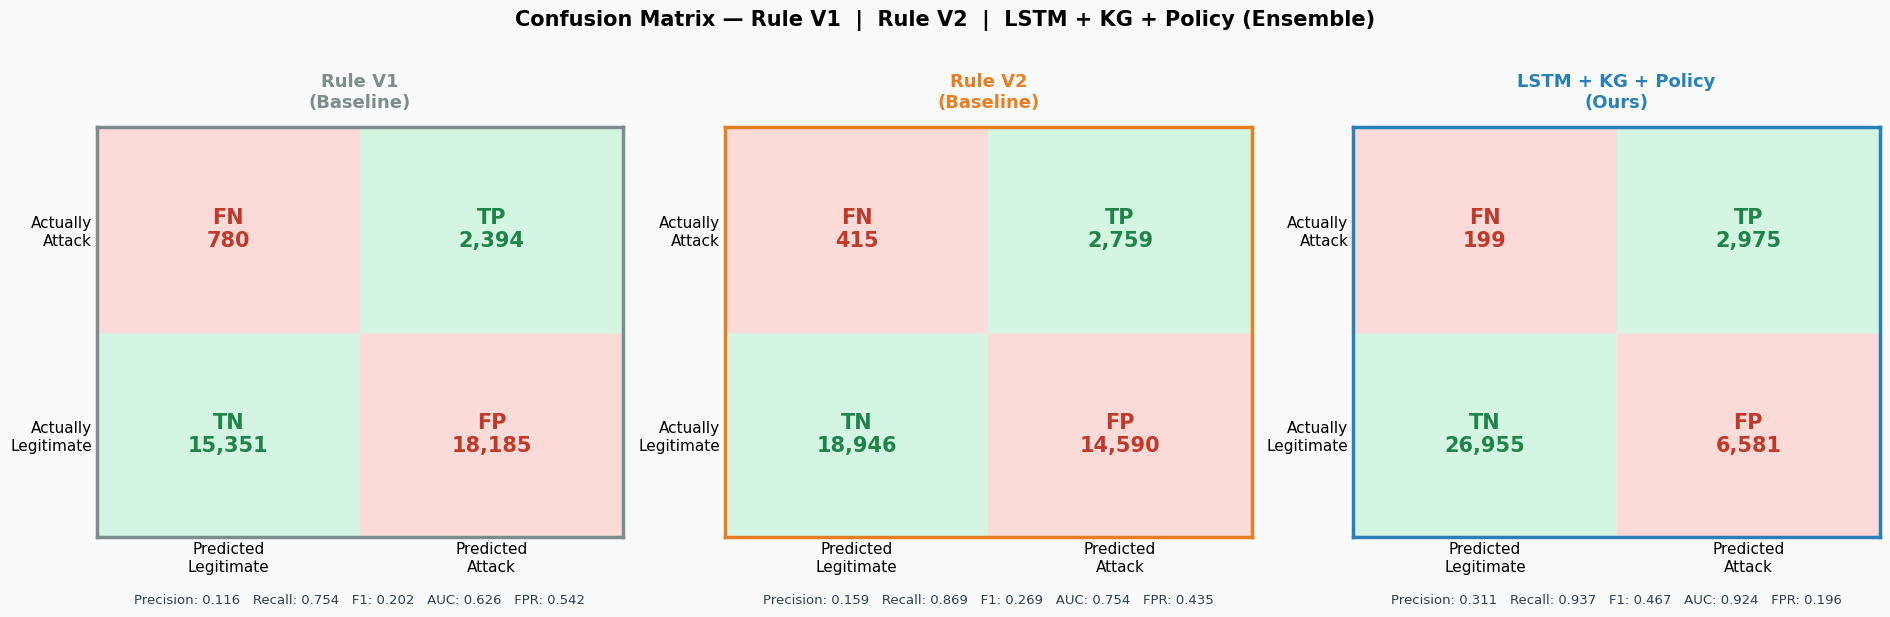

Saved: fig1_confusion_matrices.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

pred_v1     = (y_test_rule_v1     >= best_v1_thr).astype(int)
pred_v2     = (y_test_rule_v2     >= best_v2_thr).astype(int)
pred_policy = (ensemble_test_prob >= best_thr).astype(int)

models_info = [
    ('Rule V1\n(Baseline)',         pred_v1,     rule_v1_m, '#7F8C8D'),
    ('Rule V2\n(Baseline)',         pred_v2,     rule_v2_m, '#E67E22'),
    ('LSTM + KG + Policy\n(Ours)',  pred_policy, ens_m,     '#2980B9'),
]

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle(
    'Confusion Matrix — Rule V1  |  Rule V2  |  LSTM + KG + Policy (Ensemble)',
    fontsize=15, fontweight='bold', y=1.02
)

for ax, (name, pred, m, accent) in zip(axes, models_info):
    cm = confusion_matrix(y_test_aligned, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    cell_bg    = [['#D5F5E3','#FADBD8'],['#FADBD8','#D5F5E3']]
    cell_text  = [[f'TN\n{tn:,}', f'FP\n{fp:,}'],
                  [f'FN\n{fn:,}', f'TP\n{tp:,}']]
    cell_color = [['#1E8449','#C0392B'],['#C0392B','#1E8449']]

    for i in range(2):
        for j in range(2):
            ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                         color=cell_bg[i][j], zorder=0))
            ax.text(j, i, cell_text[i][j], ha='center', va='center',
                    fontsize=15, fontweight='bold', color=cell_color[i][j])

    ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Predicted\nLegitimate', 'Predicted\nAttack'], fontsize=11)
    ax.set_yticklabels(['Actually\nLegitimate', 'Actually\nAttack'],   fontsize=11)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_edgecolor(accent); spine.set_linewidth(2.5)
    ax.set_title(name, fontsize=13, fontweight='bold', color=accent, pad=14)
    ax.set_xlabel(
        f"Precision: {m['precision']:.3f}   Recall: {m['recall']:.3f}   "
        f"F1: {m['f1']:.3f}   AUC: {m['auc']:.3f}   FPR: {m['fpr']:.3f}",
        fontsize=9.5, labelpad=14, color='#2C3E50'
    )

plt.tight_layout()
plt.savefig('fig1_confusion_matrices.png', dpi=150,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print("Saved: fig1_confusion_matrices.png")

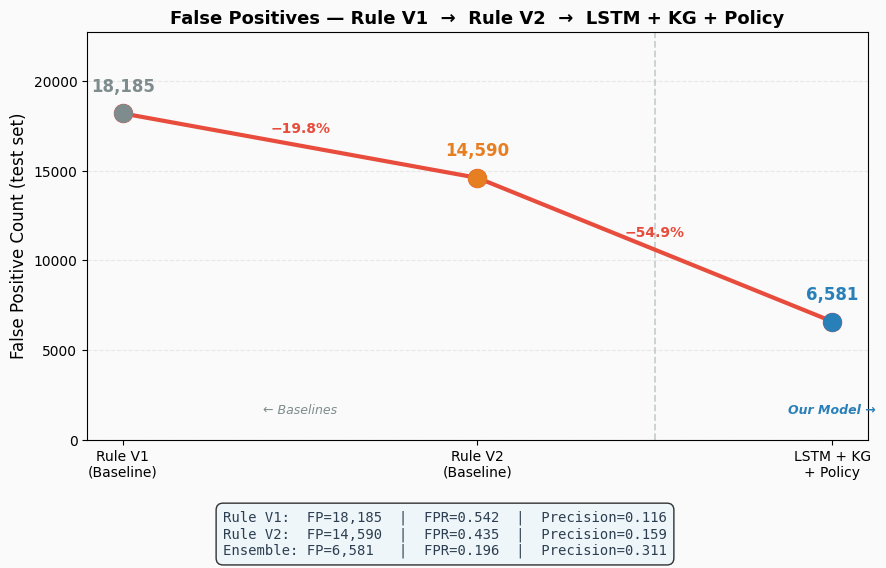

Saved: fig_fp_line.png


In [ ]:
# ── FP across models (3 lines, one per model) ──
import matplotlib.pyplot as plt
import numpy as np

models    = ['Rule V1\n(Baseline)', 'Rule V2\n(Baseline)', 'LSTM + KG\n+ Policy']
colors    = ['#7F8C8D', '#E67E22', '#2980B9']
fp_vals   = [rule_v1_m['fp'], rule_v2_m['fp'], ens_m['fp']]

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

ax.plot(models, fp_vals, marker='o', linewidth=3, markersize=13,
        color='#E74C3C', zorder=3, label='False Positives')

for i, (v, c) in enumerate(zip(fp_vals, colors)):
    ax.scatter(i, v, s=160, color=c, zorder=5)
    ax.annotate(f'{int(v):,}',
                xy=(i, v), xytext=(0, 16), textcoords='offset points',
                ha='center', fontsize=12, fontweight='bold', color=c)

# % reduction annotations on the line
for i in range(1, len(fp_vals)):
    pct = (fp_vals[i-1] - fp_vals[i]) / fp_vals[i-1] * 100
    mid_x = i - 0.5
    mid_y = (fp_vals[i-1] + fp_vals[i]) / 2
    ax.text(mid_x, mid_y + max(fp_vals)*0.04, f'−{pct:.1f}%',
            ha='center', fontsize=10, color='#E74C3C', fontweight='bold')

ax.axvline(1.5, color='#BDC3C7', linestyle='--', linewidth=1.3, alpha=0.8)
ax.text(0.5, max(fp_vals)*0.08, '← Baselines', ha='center',
        fontsize=9, color='#7F8C8D', style='italic')
ax.text(2.0, max(fp_vals)*0.08, 'Our Model →', ha='center',
        fontsize=9, color='#2980B9', style='italic', fontweight='bold')

ax.set_ylim(0, max(fp_vals) * 1.25)
ax.set_ylabel('False Positive Count (test set)', fontsize=12)
ax.set_title('False Positives — Rule V1  →  Rule V2  →  LSTM + KG + Policy',
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.25, linestyle='--')

# metrics strip at bottom
metrics_text = (
    f"Rule V1:  FP={rule_v1_m['fp']:,}  |  FPR={rule_v1_m['fpr']:.3f}  |  Precision={rule_v1_m['precision']:.3f}\n"
    f"Rule V2:  FP={rule_v2_m['fp']:,}  |  FPR={rule_v2_m['fpr']:.3f}  |  Precision={rule_v2_m['precision']:.3f}\n"
    f"Ensemble: FP={ens_m['fp']:,}   |  FPR={ens_m['fpr']:.3f}  |  Precision={ens_m['precision']:.3f}"
)
fig.text(0.5, -0.12, metrics_text, ha='center', fontsize=10,
         color='#2C3E50', family='monospace',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#EBF5FB', alpha=0.8))

plt.tight_layout()
plt.savefig('fig_fp_line.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print("Saved: fig_fp_line.png")

FP / FN reduction (bar + line + % annotation)


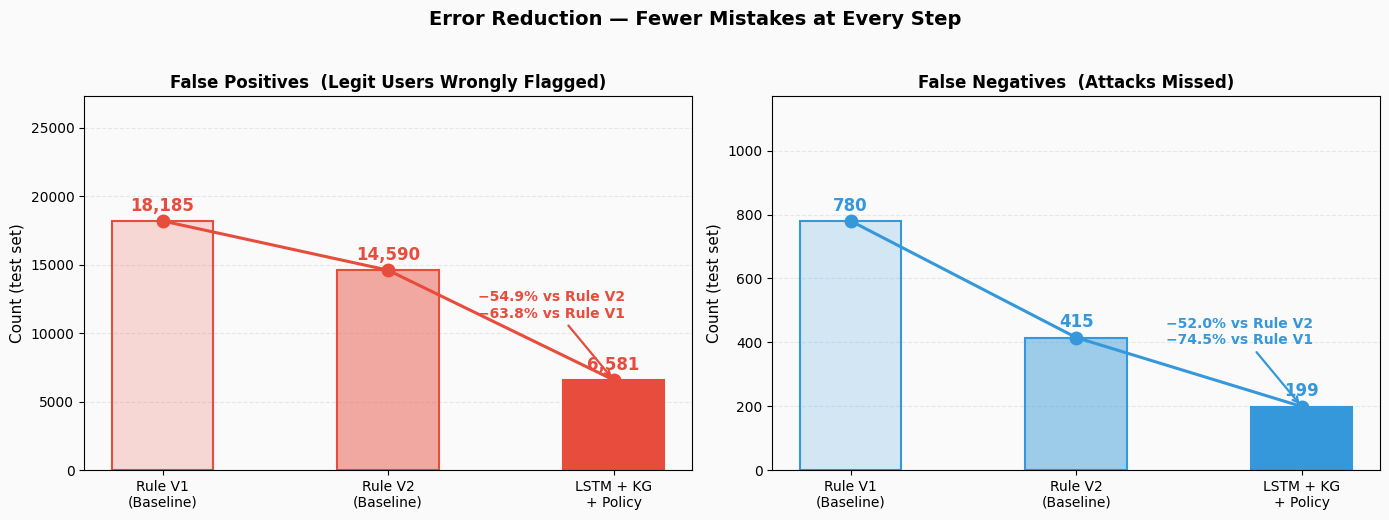

Saved: fig4_fp_fn_reduction.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Error Reduction — Fewer Mistakes at Every Step',
             fontsize=14, fontweight='bold', y=1.03)

stages_short = ['Rule V1\n(Baseline)', 'Rule V2\n(Baseline)', 'LSTM + KG\n+ Policy']

for ax, key, title, color in zip(
    axes,
    ['fp', 'fn'],
    ['False Positives  (Legit Users Wrongly Flagged)',
     'False Negatives  (Attacks Missed)'],
    ['#E74C3C', '#3498DB']
):
    vals = [rule_v1_m[key], rule_v2_m[key], ens_m[key]]
    bars = ax.bar(stages_short, vals,
                  color=[f'{color}33', f'{color}77', color],
                  edgecolor=color, linewidth=1.5, width=0.45, zorder=2)
    ax.plot(stages_short, vals, marker='o', color=color,
            linewidth=2.2, markersize=9, zorder=3)

    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.025,
                f'{int(v):,}', ha='center', va='bottom',
                fontsize=12, fontweight='bold', color=color)

    pct_v2 = (vals[1] - vals[2]) / vals[1] * 100
    pct_v1 = (vals[0] - vals[2]) / vals[0] * 100
    ax.annotate(
        f'−{pct_v2:.1f}% vs Rule V2\n−{pct_v1:.1f}% vs Rule V1',
        xy=(2, vals[2]),
        xytext=(1.4, vals[2] + max(vals) * 0.25),
        fontsize=10, fontweight='bold', color=color,
        arrowprops=dict(arrowstyle='->', color=color, lw=1.6)
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count (test set)', fontsize=11)
    ax.set_ylim(0, max(vals) * 1.5)
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    ax.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.savefig('fig4_fp_fn_reduction.png', dpi=150,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print("Saved: fig4_fp_fn_reduction.png")

Line chart (3 lines, your professor's specific request)

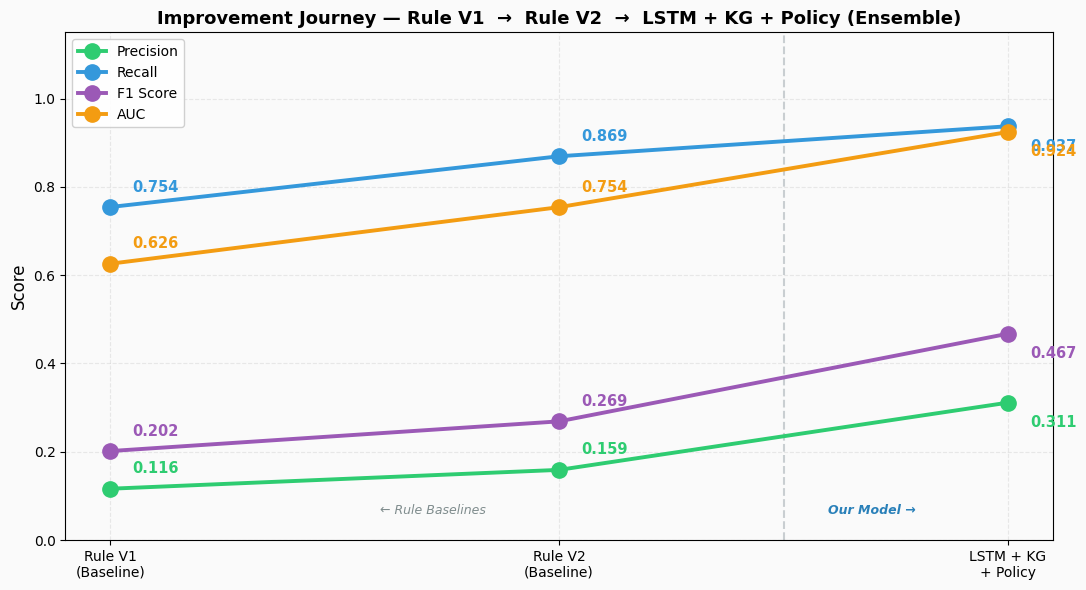

Saved: fig2_improvement_journey.png


In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

stages = ['Rule V1\n(Baseline)', 'Rule V2\n(Baseline)', 'LSTM + KG\n+ Policy']

journey = {
    'Precision': ('#2ECC71',  [rule_v1_m['precision'], rule_v2_m['precision'], ens_m['precision']]),
    'Recall':    ('#3498DB',  [rule_v1_m['recall'],    rule_v2_m['recall'],    ens_m['recall']]),
    'F1 Score':  ('#9B59B6',  [rule_v1_m['f1'],        rule_v2_m['f1'],        ens_m['f1']]),
    'AUC':       ('#F39C12',  [rule_v1_m['auc'],       rule_v2_m['auc'],       ens_m['auc']]),
}

for metric, (color, vals) in journey.items():
    ax.plot(stages, vals, marker='o', linewidth=2.8, markersize=11,
            label=metric, color=color, zorder=3)
    for i, v in enumerate(vals):
        offset = 0.035 if i < 2 else -0.055
        ax.annotate(f'{v:.3f}',
                    xy=(i, v), xytext=(i + 0.05, v + offset),
                    fontsize=10.5, fontweight='bold', color=color)

# divider before our model
ax.axvline(1.5, color='#BDC3C7', linestyle='--', linewidth=1.5, alpha=0.8)
ax.text(0.6, 0.06, '← Rule Baselines', fontsize=9, color='#7F8C8D', style='italic')
ax.text(1.6, 0.06, 'Our Model →',      fontsize=9, color='#2980B9', style='italic',
        fontweight='bold')

ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(
    'Improvement Journey — Rule V1  →  Rule V2  →  LSTM + KG + Policy (Ensemble)',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.25, linestyle='--')

plt.tight_layout()
plt.savefig('fig2_improvement_journey.png', dpi=150,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print("Saved: fig2_improvement_journey.png")

Grouped bar (all 6 metrics)

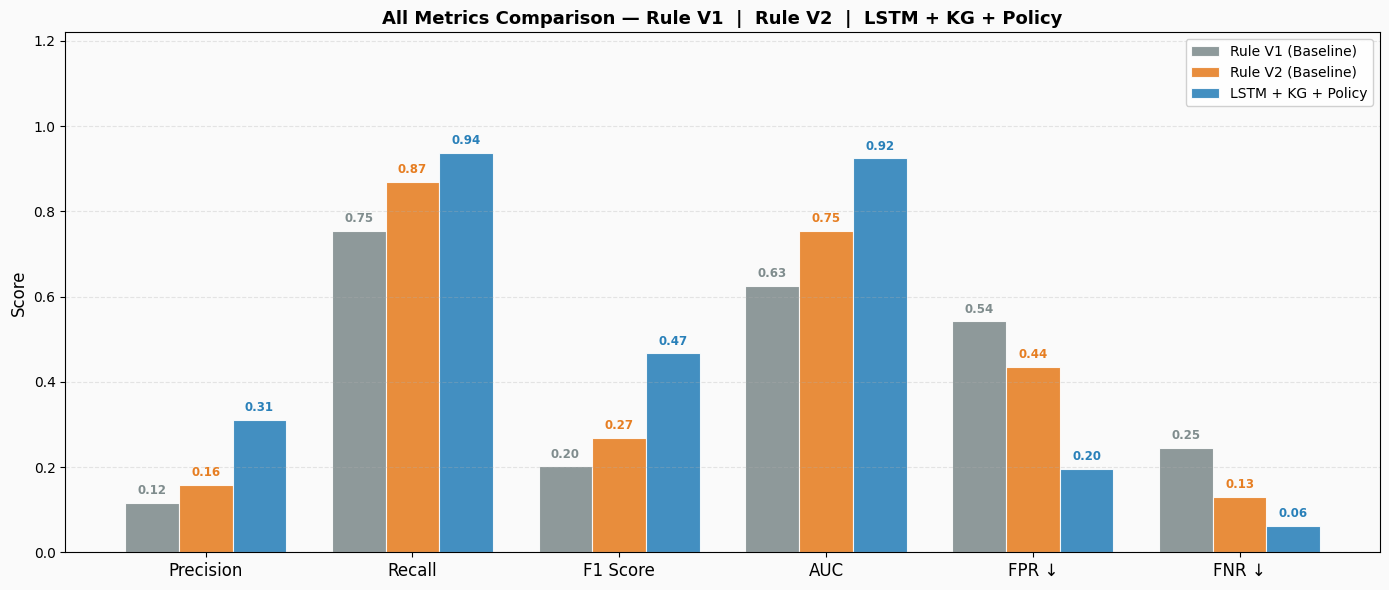

Saved: fig3_metrics_comparison.png


In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

model_names  = ['Rule V1 (Baseline)', 'Rule V2 (Baseline)', 'LSTM + KG + Policy']
bar_colors   = ['#7F8C8D', '#E67E22', '#2980B9']
metric_names = ['Precision', 'Recall', 'F1 Score', 'AUC', 'FPR ↓', 'FNR ↓']
metric_keys  = ['precision', 'recall', 'f1', 'auc', 'fpr', 'fnr']
model_results = [rule_v1_m, rule_v2_m, ens_m]

x     = np.arange(len(metric_names))
width = 0.26

for i, (name, color, res) in enumerate(zip(model_names, bar_colors, model_results)):
    vals = [res[k] for k in metric_keys]
    bars = ax.bar(x + i*width, vals, width, label=name,
                  color=color, alpha=0.88, edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.013,
                f'{v:.2f}', ha='center', va='bottom',
                fontsize=8.5, fontweight='bold', color=color)

ax.set_xticks(x + width)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylim(0, 1.22)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(
    'All Metrics Comparison — Rule V1  |  Rule V2  |  LSTM + KG + Policy',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('fig3_metrics_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print("Saved: fig3_metrics_comparison.png")

PR curve + ROC curve

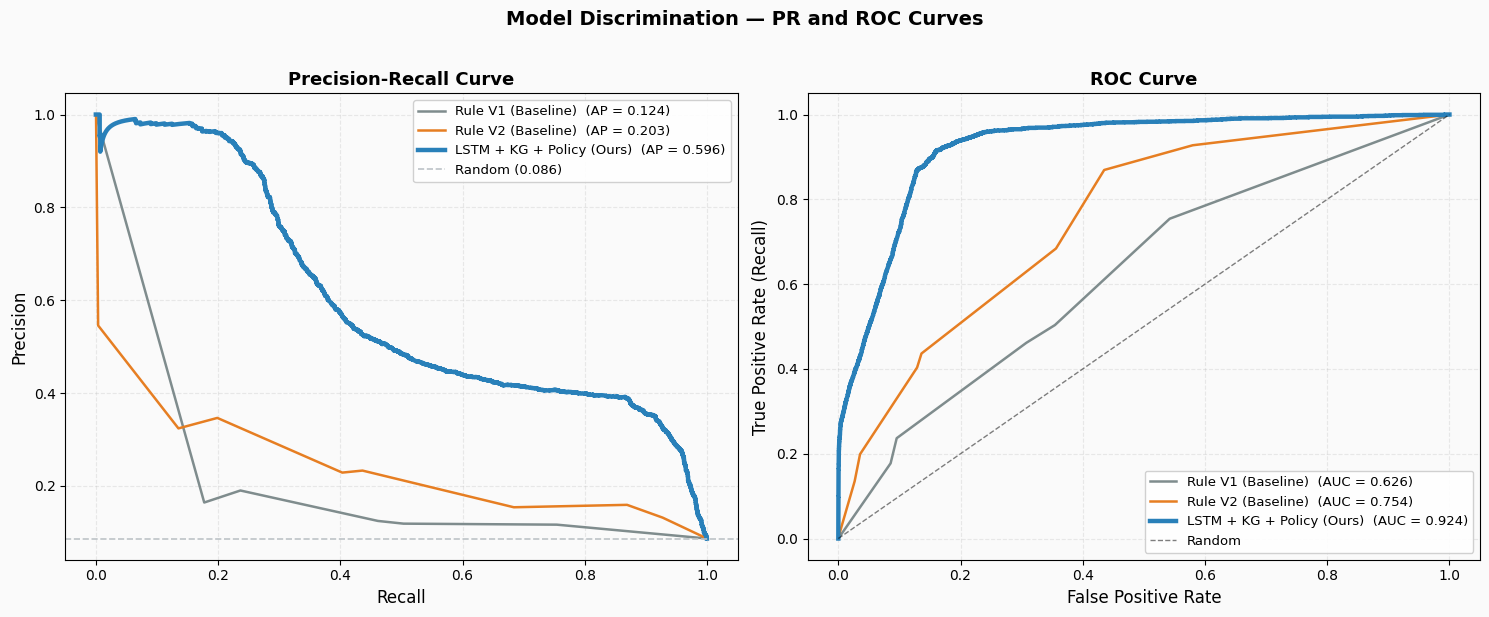

Saved: fig5_pr_roc_curves.png


In [ ]:
from sklearn.metrics import (precision_recall_curve, average_precision_score,
                              roc_curve, roc_auc_score)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#FAFAFA')

named_scores = [
    ('Rule V1 (Baseline)',         y_test_rule_v1,     '#7F8C8D', 1.8),
    ('Rule V2 (Baseline)',         y_test_rule_v2,     '#E67E22', 1.8),
    ('LSTM + KG + Policy (Ours)',  ensemble_test_prob, '#2980B9', 3.2),
]

for name, scores, color, lw in named_scores:
    prec_c, rec_c, _ = precision_recall_curve(y_test_aligned, scores)
    ap = average_precision_score(y_test_aligned, scores)
    axes[0].plot(rec_c, prec_c, color=color, linewidth=lw,
                 label=f'{name}  (AP = {ap:.3f})')

axes[0].axhline(y_test_aligned.mean(), color='#BDC3C7', linestyle='--',
                linewidth=1.2, label=f'Random ({y_test_aligned.mean():.3f})')
axes[0].set_xlabel('Recall', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9.5, framealpha=0.9)
axes[0].grid(True, alpha=0.25, linestyle='--')
axes[0].set_facecolor('#FAFAFA')

for name, scores, color, lw in named_scores:
    fpr_c, tpr_c, _ = roc_curve(y_test_aligned, scores)
    auc_val = roc_auc_score(y_test_aligned, scores)
    axes[1].plot(fpr_c, tpr_c, color=color, linewidth=lw,
                 label=f'{name}  (AUC = {auc_val:.3f})')

axes[1].plot([0,1],[0,1], 'k--', linewidth=1, label='Random', alpha=0.5)
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate (Recall)', fontsize=12)
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9.5, framealpha=0.9)
axes[1].grid(True, alpha=0.25, linestyle='--')
axes[1].set_facecolor('#FAFAFA')

plt.suptitle('Model Discrimination — PR and ROC Curves',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig5_pr_roc_curves.png', dpi=150,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print("Saved: fig5_pr_roc_curves.png")

Publication summary table


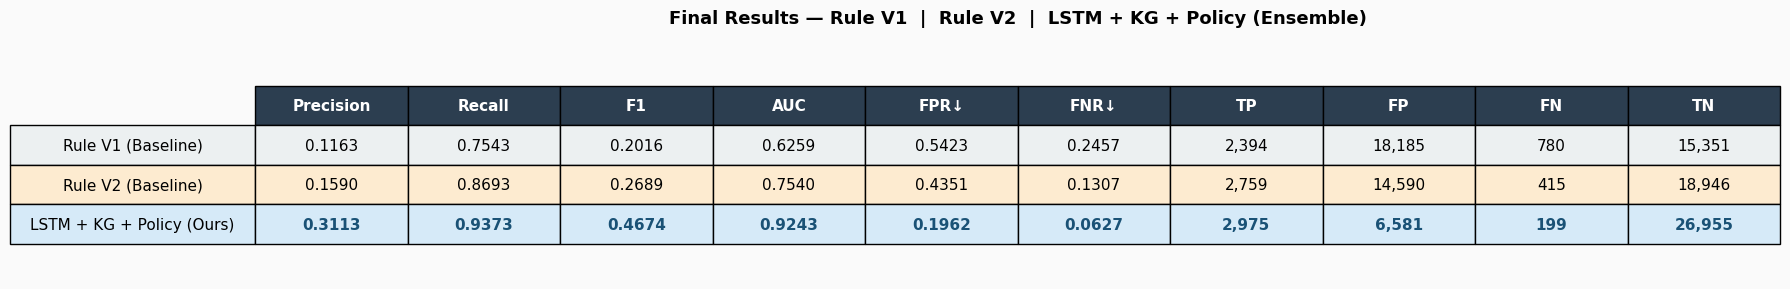

Saved: fig6_results_table.png


In [ ]:
rows = {
    'Rule V1 (Baseline)':        rule_v1_m,
    'Rule V2 (Baseline)':        rule_v2_m,
    'LSTM + KG + Policy (Ours)': ens_m,
}
display_cols = ['precision','recall','f1','auc','fpr','fnr','tp','fp','fn','tn']
col_labels   = ['Precision','Recall','F1','AUC','FPR↓','FNR↓','TP','FP','FN','TN']

table_data = []
for m in rows.values():
    row = []
    for c in display_cols:
        v = m[c]
        row.append(f'{v:.4f}' if isinstance(v, float) else f'{int(v):,}')
    table_data.append(row)

fig, ax = plt.subplots(figsize=(18, 3))
fig.patch.set_facecolor('#FAFAFA')
ax.axis('off')

tbl = ax.table(
    cellText  = table_data,
    rowLabels = list(rows.keys()),
    colLabels = col_labels,
    cellLoc   = 'center',
    rowLoc    = 'center',
    loc       = 'center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.0, 2.4)

# header
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#2C3E50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

# row colours
row_colors = ['#ECF0F1', '#FDEBD0', '#D6EAF8']
for i, rc in enumerate(row_colors):
    tbl[i+1, -1].set_facecolor(rc)
    for j in range(len(col_labels)):
        tbl[i+1, j].set_facecolor(rc)

# bold our model
for j in range(len(col_labels)):
    tbl[3, j].set_text_props(fontweight='bold', color='#1A5276')

ax.set_title(
    'Final Results — Rule V1  |  Rule V2  |  LSTM + KG + Policy (Ensemble)',
    fontsize=13, fontweight='bold', pad=20
)
plt.tight_layout()
plt.savefig('fig6_results_table.png', dpi=150,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print("Saved: fig6_results_table.png")

In [ ]:
# fig, ax = plt.subplots(figsize=(9, 6))
# fig.patch.set_facecolor('white')

# model_labels  = ['Rule V1\n(Baseline)', 'Rule V2\n(Baseline)', 'LSTM + KG\n+ Policy']
# action_colors = {'Allow': '#2ECC71', 'Step-Up': '#F39C12', 'Block': '#E74C3C'}
# models_list   = list(all_ac.values())

# bottoms = np.zeros(3)
# totals  = np.array([ac['Allow'] + ac['Step-Up'] + ac['Block']
#                     for ac in models_list], dtype=float)

# for action, color in action_colors.items():
#     raw  = np.array([ac[action] for ac in models_list], dtype=float)
#     vals = raw / totals * 100

#     bars = ax.bar(model_labels, vals, bottom=bottoms,
#                   color=color, label=action,
#                   alpha=0.88, edgecolor='white', linewidth=0.8)

#     for i, (bar, v) in enumerate(zip(bars, vals)):
#         if v > 1.5:
#             ax.text(bar.get_x() + bar.get_width() / 2,
#                     bottoms[i] + v / 2,
#                     f'{v:.1f}%', ha='center', va='center',
#                     fontsize=10, fontweight='bold', color='white')
#     bottoms += vals

# ax.set_ylabel('Percentage of Logins (%)', fontsize=12)
# ax.set_title('Proportional Action Distribution — Allow | Step-Up | Block',
#              fontsize=12, fontweight='bold')
# ax.legend(fontsize=10, loc='upper right')
# ax.grid(axis='y', alpha=0.25, linestyle='--')
# ax.set_ylim(0, 115)

# plt.tight_layout()
# plt.savefig('fig_action_distribution_pct.png', dpi=150,
#             bbox_inches='tight', facecolor='white')
# plt.show()
# print("Saved: fig_action_distribution_pct.png")

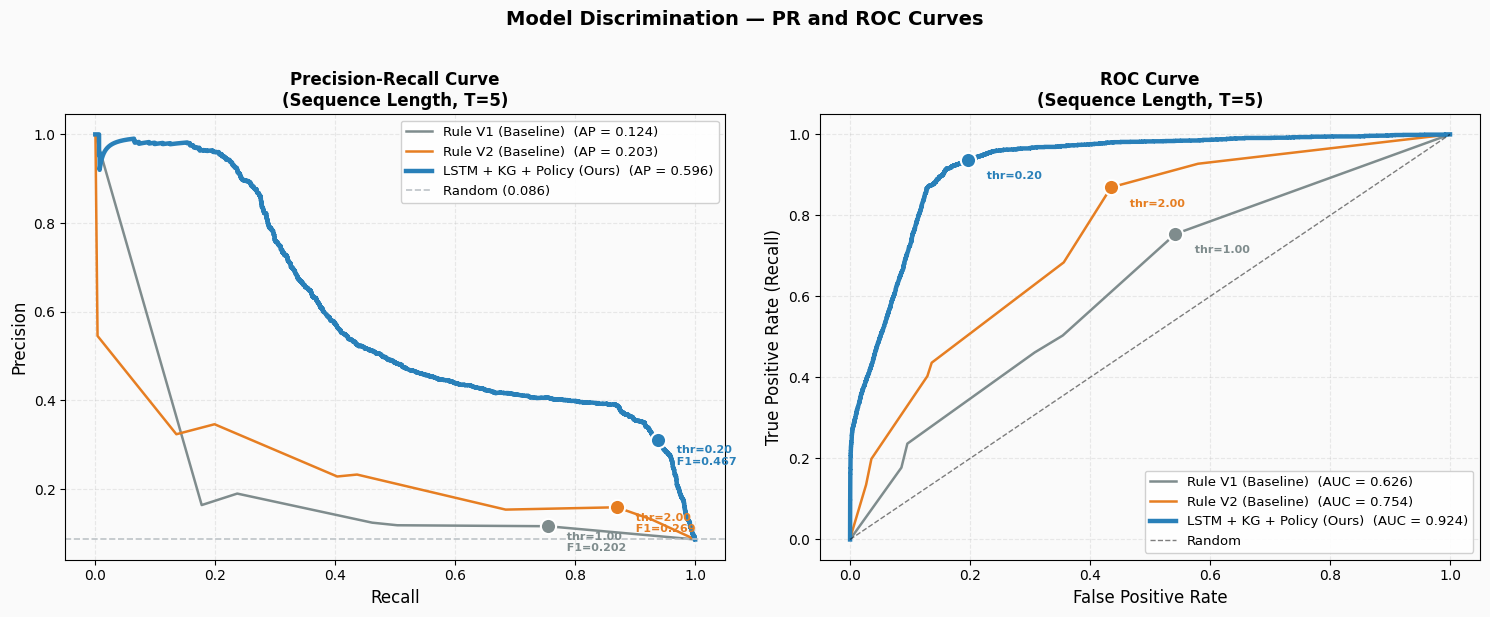

Saved: fig5_pr_roc_curves.png


In [ ]:
from sklearn.metrics import (precision_recall_curve, average_precision_score,
                              roc_curve, roc_auc_score)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#FAFAFA')

named_scores = [
    ('Rule V1 (Baseline)',        y_test_rule_v1,     '#7F8C8D', 1.8, best_v1_thr),
    ('Rule V2 (Baseline)',        y_test_rule_v2,     '#E67E22', 1.8, best_v2_thr),
    ('LSTM + KG + Policy (Ours)', ensemble_test_prob, '#2980B9', 3.2, best_thr),
]

# ── PR Curve ──
for name, scores, color, lw, thr in named_scores:
    prec_c, rec_c, _ = precision_recall_curve(y_test_aligned, scores)
    ap = average_precision_score(y_test_aligned, scores)
    axes[0].plot(rec_c, prec_c, color=color, linewidth=lw,
                 label=f'{name}  (AP = {ap:.3f})')

    # ── operating point at locked threshold ──
    m = evaluate_model(y_test_aligned, scores, thr)
    axes[0].scatter(m['recall'], m['precision'],
                    color=color, s=120, zorder=6,
                    edgecolors='white', linewidths=1.5)
    axes[0].annotate(f'  thr={thr:.2f}\n  F1={m["f1"]:.3f}',
                     xy=(m['recall'], m['precision']),
                     xytext=(8, -18), textcoords='offset points',
                     fontsize=8, color=color, fontweight='bold')

axes[0].axhline(y_test_aligned.mean(), color='#BDC3C7', linestyle='--',
                linewidth=1.2, label=f'Random ({y_test_aligned.mean():.3f})')
axes[0].set_xlabel('Recall', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title('Precision-Recall Curve\n(Sequence Length, T=5)',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9.5, framealpha=0.9)
axes[0].grid(True, alpha=0.25, linestyle='--')
axes[0].set_facecolor('#FAFAFA')

# ── ROC Curve ──
for name, scores, color, lw, thr in named_scores:
    fpr_c, tpr_c, _ = roc_curve(y_test_aligned, scores)
    auc_val = roc_auc_score(y_test_aligned, scores)
    axes[1].plot(fpr_c, tpr_c, color=color, linewidth=lw,
                 label=f'{name}  (AUC = {auc_val:.3f})')

    # ── operating point ──
    m = evaluate_model(y_test_aligned, scores, thr)
    axes[1].scatter(m['fpr'], m['recall'],
                    color=color, s=120, zorder=6,
                    edgecolors='white', linewidths=1.5)
    axes[1].annotate(f'  thr={thr:.2f}',
                     xy=(m['fpr'], m['recall']),
                     xytext=(8, -14), textcoords='offset points',
                     fontsize=8, color=color, fontweight='bold')

axes[1].plot([0,1],[0,1], 'k--', linewidth=1, label='Random', alpha=0.5)
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate (Recall)', fontsize=12)
axes[1].set_title('ROC Curve\n(Sequence Length, T=5)',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9.5, framealpha=0.9)
axes[1].grid(True, alpha=0.25, linestyle='--')
axes[1].set_facecolor('#FAFAFA')

plt.suptitle('Model Discrimination — PR and ROC Curves',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig5_pr_roc_curves.png', dpi=150,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print("Saved: fig5_pr_roc_curves.png")

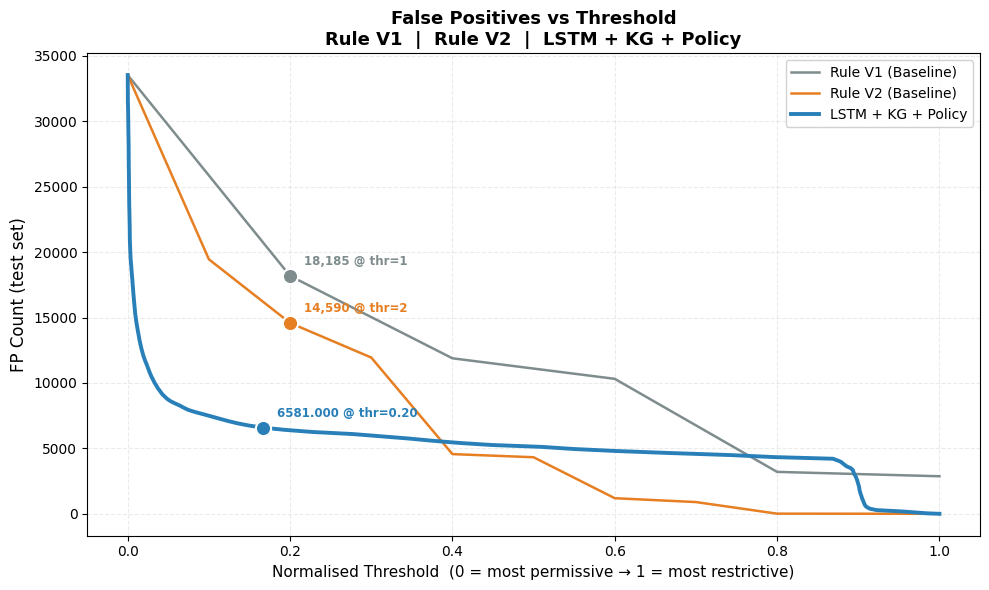

Saved: fig_line_fp.png


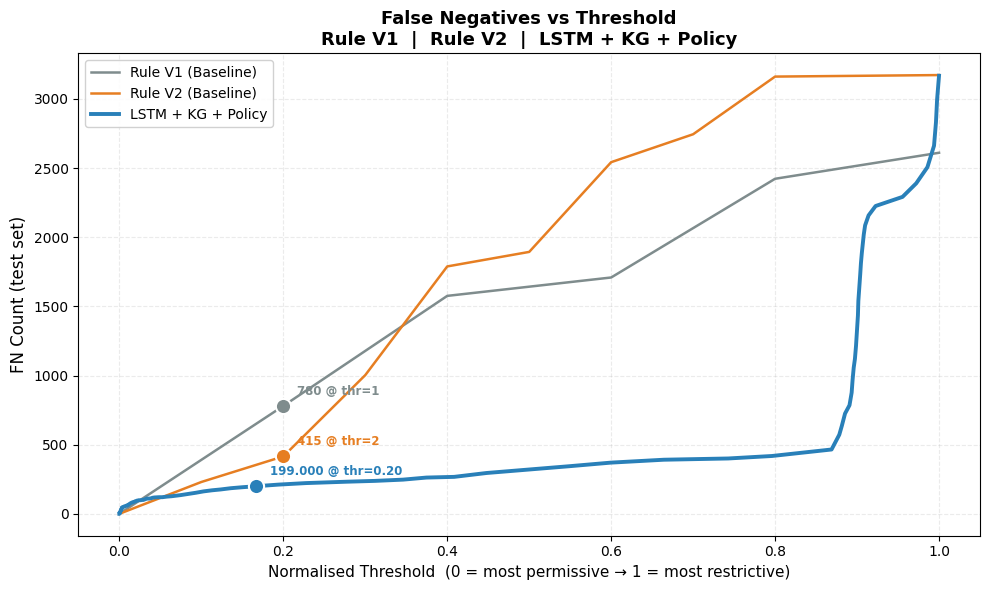

Saved: fig_line_fn.png


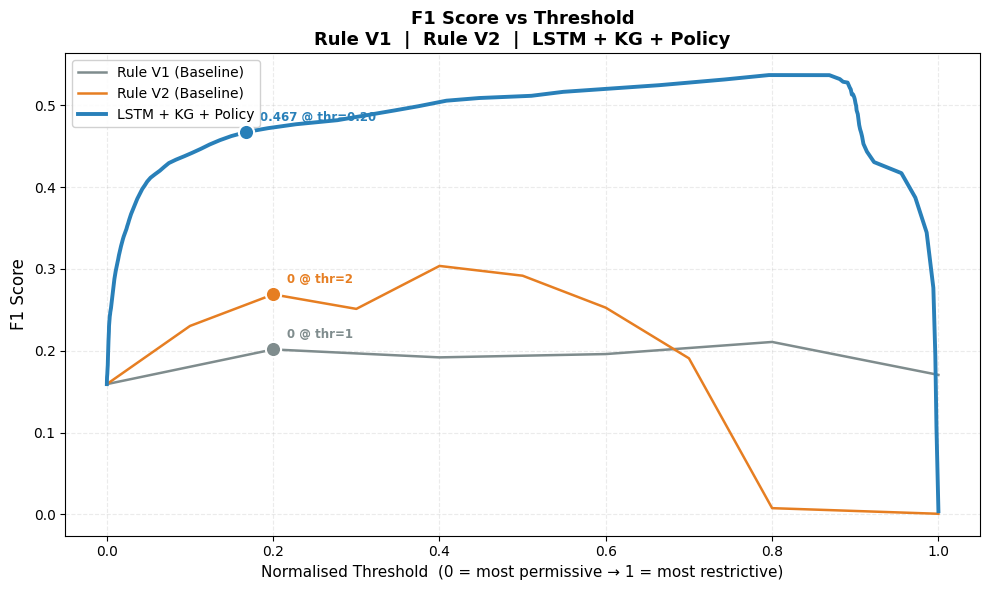

Saved: fig_line_f1.png


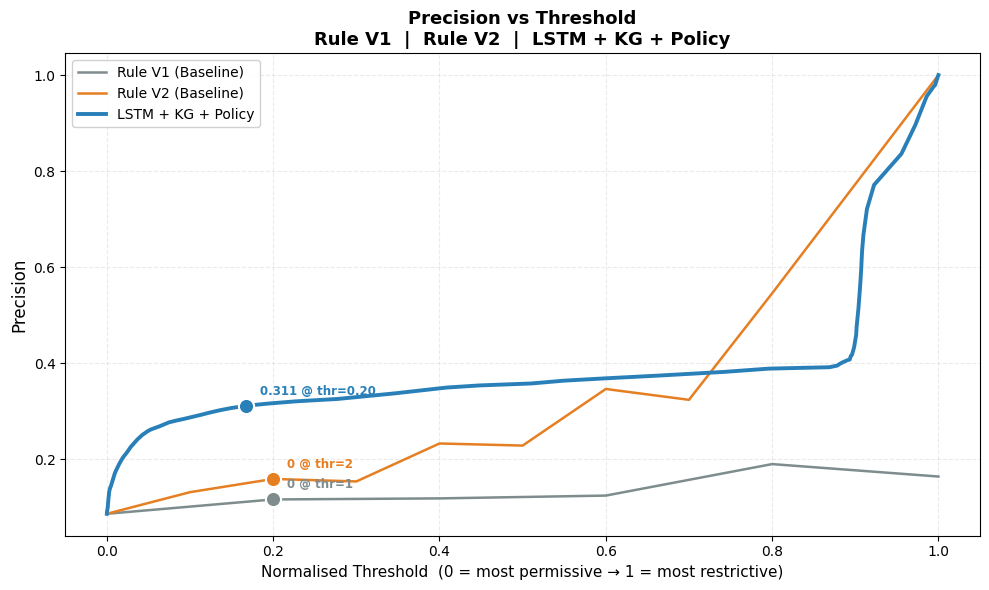

Saved: fig_line_prec.png


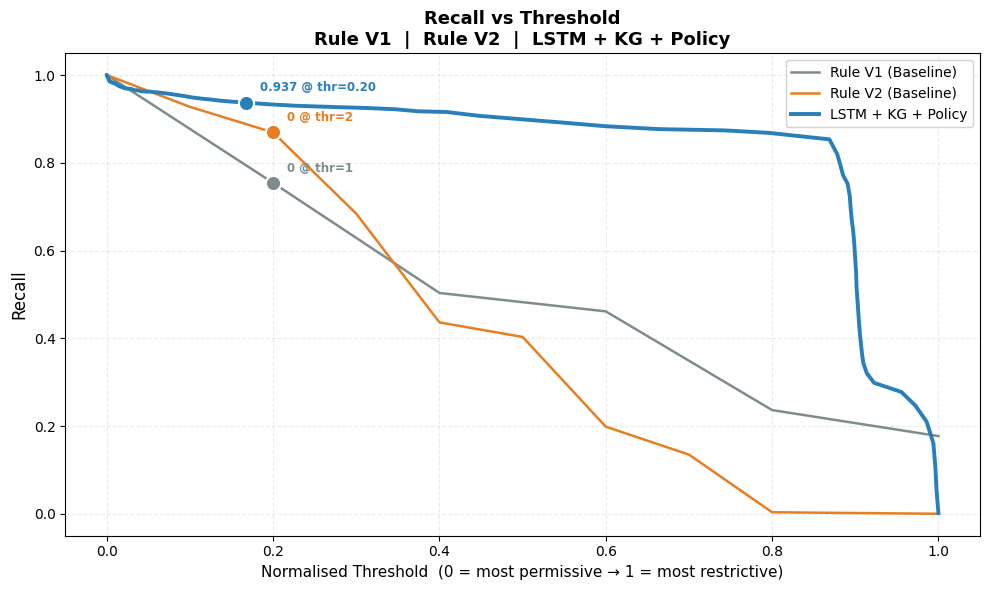

Saved: fig_line_rec.png


In [ ]:
# ── 3 Lines per Figure — FP, FN, F1, Precision, Recall vs Normalised Threshold ──
from sklearn.metrics import confusion_matrix, precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

def compute_curve(scores, y_true, n_points=200):
    """Compute FP/FN/Precision/Recall/F1 across thresholds."""
    _, _, thr_arr = precision_recall_curve(y_true, scores)
    step     = max(1, len(thr_arr) // n_points)
    thr_s    = thr_arr[::step]

    fp_c, fn_c, prec_c, rec_c, f1_c = [], [], [], [], []
    for t in thr_s:
        pred = (scores >= t).astype(int)
        tn_, fp_, fn_, tp_ = confusion_matrix(y_true, pred).ravel()
        p  = tp_ / (tp_ + fp_ + 1e-12)
        r  = tp_ / (tp_ + fn_ + 1e-12)
        fp_c.append(fp_);   fn_c.append(fn_)
        prec_c.append(p);   rec_c.append(r)
        f1_c.append(2*p*r/(p+r+1e-12))

    # normalise threshold to 0-1
    thr_norm = (thr_s - thr_s.min()) / (thr_s.max() - thr_s.min() + 1e-12)
    return thr_norm, fp_c, fn_c, prec_c, rec_c, f1_c

named = [
    ('Rule V1 (Baseline)',        y_test_rule_v1,     '#7F8C8D', 1.8, best_v1_thr),
    ('Rule V2 (Baseline)',        y_test_rule_v2,     '#E67E22', 1.8, best_v2_thr),
    ('LSTM + KG + Policy', ensemble_test_prob, '#2980B9', 2.8, best_thr),
]

# pre-compute all curves
curves = {}
for name, scores, color, lw, thr in named:
    thr_norm, fp_c, fn_c, prec_c, rec_c, f1_c = compute_curve(scores, y_test_aligned)
    # find operating point index (closest normalised threshold)
    thr_arr_raw = precision_recall_curve(y_test_aligned, scores)[2]
    step = max(1, len(thr_arr_raw) // 200)
    thr_s = thr_arr_raw[::step]
    thr_norm_raw = (thr_s - thr_s.min()) / (thr_s.max() - thr_s.min() + 1e-12)
    op_norm = (thr - thr_arr_raw.min()) / (thr_arr_raw.max() - thr_arr_raw.min() + 1e-12)
    op_norm = np.clip(op_norm, 0, 1)
    curves[name] = dict(thr_norm=thr_norm, fp=fp_c, fn=fn_c,
                        prec=prec_c, rec=rec_c, f1=f1_c,
                        color=color, lw=lw, op_norm=op_norm,
                        scores=scores, thr=thr)

# ── 5 separate figures, one metric each, 3 lines each ──
panels = [
    ('False Positives',  'fp',   'FP Count (test set)',   'fig_line_fp.png'),
    ('False Negatives',  'fn',   'FN Count (test set)',   'fig_line_fn.png'),
    ('F1 Score',         'f1',   'F1 Score',              'fig_line_f1.png'),
    ('Precision',        'prec', 'Precision',             'fig_line_prec.png'),
    ('Recall',           'rec',  'Recall',                'fig_line_rec.png'),
]

for metric_name, key, ylabel, fname in panels:
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('white')

    for name, scores, color, lw, thr in named:
        c = curves[name]
        ax.plot(c['thr_norm'], c[key],
                color=color, linewidth=lw,
                label=name)

        # operating point dot
        m = evaluate_model(y_test_aligned, scores, thr)
        op_val = m['fp'] if key=='fp' else \
                 m['fn'] if key=='fn' else \
                 m['f1'] if key=='f1' else \
                 m['precision'] if key=='prec' else m['recall']

        ax.scatter([c['op_norm']], [op_val],
                   color=color, s=120, zorder=6,
                   edgecolors='white', linewidths=1.5)
        ax.annotate(f'{op_val:.3f} @ thr={thr:.2f}' if thr < 1 else f'{int(op_val):,} @ thr={thr:.0f}',
                    xy=(c['op_norm'], op_val),
                    xytext=(10, 8), textcoords='offset points',
                    fontsize=8.5, fontweight='bold', color=color)

    ax.set_xlabel('Normalised Threshold  (0 = most permissive → 1 = most restrictive)',
                  fontsize=11)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f'{metric_name} vs Threshold\n'
                 f'Rule V1  |  Rule V2  |  LSTM + KG + Policy',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=10, framealpha=0.9)
    ax.grid(True, alpha=0.25, linestyle='--')
    ax.set_facecolor('white')

    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {fname}")

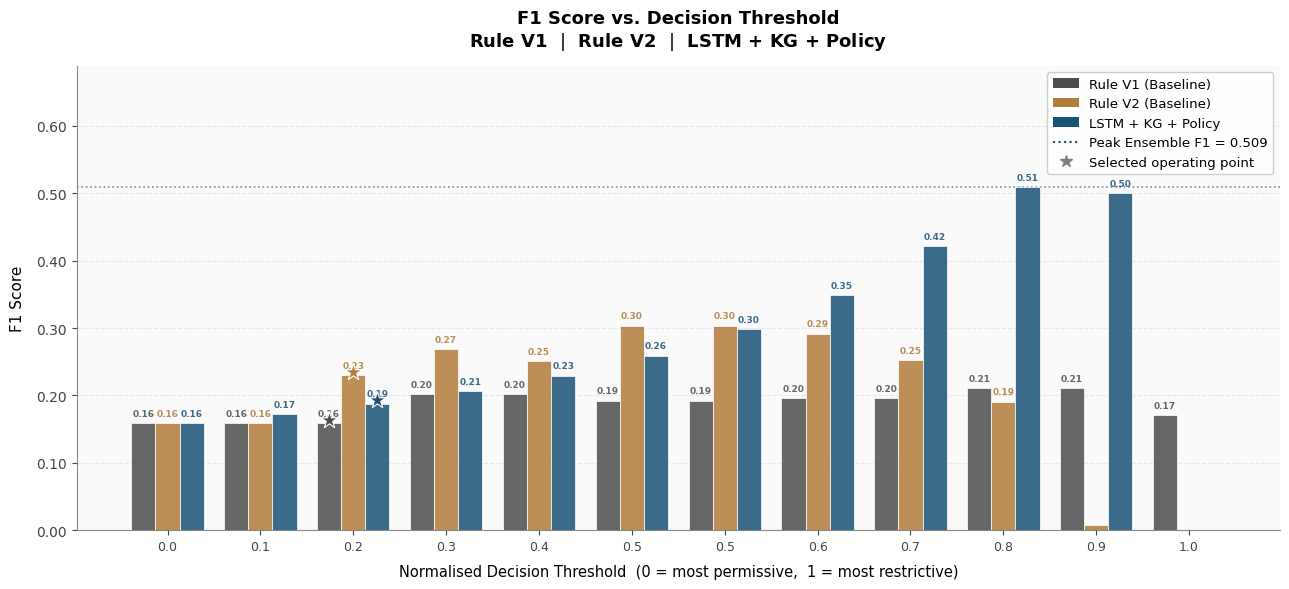

In [ ]:
# ── F1 Score vs Threshold — IEEE publication-quality grouped bar ──
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import numpy as np
from sklearn.metrics import precision_recall_curve, confusion_matrix

# ── compute F1 at sampled thresholds for each model ──
def f1_curve_sampled(scores, y_true, n_bins=12):
    _, _, thr_arr = precision_recall_curve(y_true, scores)
    # pick n_bins evenly spaced thresholds
    indices = np.linspace(0, len(thr_arr)-1, n_bins, dtype=int)
    thr_s   = thr_arr[indices]
    f1_vals = []
    for t in thr_s:
        pred = (scores >= t).astype(int)
        tn_, fp_, fn_, tp_ = confusion_matrix(y_true, pred).ravel()
        p  = tp_ / (tp_ + fp_ + 1e-12)
        r  = tp_ / (tp_ + fn_ + 1e-12)
        f1_vals.append(2*p*r/(p+r+1e-12))
    # normalise threshold labels to 0–1
    thr_norm = np.linspace(0, 1, n_bins)
    return thr_norm, f1_vals

N_BINS = 12

t_v1,  f1_v1  = f1_curve_sampled(y_test_rule_v1,     y_test_aligned, N_BINS)
t_v2,  f1_v2  = f1_curve_sampled(y_test_rule_v2,     y_test_aligned, N_BINS)
t_ens, f1_ens = f1_curve_sampled(ensemble_test_prob,  y_test_aligned, N_BINS)

# ── IEEE colour palette — muted, print-safe ──
C_V1  = '#4D4D4D'   # dark grey
C_V2  = '#B07D3A'   # warm amber
C_ENS = '#1A5276'   # deep navy

x      = np.arange(N_BINS)
width  = 0.26
offset = [-width, 0, width]

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('#FAFAFA')

# ── bars ──
bars_v1  = ax.bar(x + offset[0], f1_v1,  width, color=C_V1,
                  alpha=0.85, edgecolor='white', linewidth=0.6, zorder=3)
bars_v2  = ax.bar(x + offset[1], f1_v2,  width, color=C_V2,
                  alpha=0.85, edgecolor='white', linewidth=0.6, zorder=3)
bars_ens = ax.bar(x + offset[2], f1_ens, width, color=C_ENS,
                  alpha=0.85, edgecolor='white', linewidth=0.6, zorder=3)

# ── value labels on top of each bar ──
for bars, vals in [(bars_v1, f1_v1), (bars_v2, f1_v2), (bars_ens, f1_ens)]:
    for bar, v in zip(bars, vals):
        if v > 0.02:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.008,
                    f'{v:.2f}',
                    ha='center', va='bottom',
                    fontsize=6.5, fontweight='bold',
                    color=bar.get_facecolor(),
                    rotation=90 if v < 0.15 else 0)

# ── mark operating points ──
op_v1  = (best_v1_thr  - y_test_rule_v1.min())  / (y_test_rule_v1.max()  - y_test_rule_v1.min()  + 1e-12)
op_v2  = (best_v2_thr  - y_test_rule_v2.min())  / (y_test_rule_v2.max()  - y_test_rule_v2.min()  + 1e-12)
op_ens = (best_thr     - ensemble_test_prob.min()) / (ensemble_test_prob.max() - ensemble_test_prob.min() + 1e-12)

for op_norm, f1_arr, color, label, off in [
    (op_v1,  f1_v1,  C_V1,  f'V1 thr={best_v1_thr}',   offset[0]),
    (op_v2,  f1_v2,  C_V2,  f'V2 thr={best_v2_thr}',   offset[1]),
    (op_ens, f1_ens, C_ENS, f'Ens thr={best_thr:.2f}', offset[2]),
]:
    # find nearest bin
    idx = int(np.clip(round(op_norm * (N_BINS-1)), 0, N_BINS-1))
    bar_x = x[idx] + off
    bar_h = f1_arr[idx]
    ax.scatter([bar_x], [bar_h + 0.005], marker='*', s=160,
               color=color, zorder=6, edgecolors='white', linewidths=0.8)

# ── x axis labels ──
ax.set_xticks(x)
ax.set_xticklabels([f'{v:.1f}' for v in np.linspace(0, 1, N_BINS)],
                   fontsize=9)

# ── reference line at max ensemble F1 ──
max_ens = max(f1_ens)
ax.axhline(max_ens, color=C_ENS, linestyle=':', linewidth=1.2, alpha=0.6,
           label=f'Peak Ensemble F1 = {max_ens:.3f}')

# ── styling ──
ax.set_ylim(0, min(1.0, max(f1_ens + f1_v1 + f1_v2) + 0.18))
ax.set_xlabel('Normalised Decision Threshold  (0 = most permissive,  1 = most restrictive)',
              fontsize=10.5, labelpad=8)
ax.set_ylabel('F1 Score', fontsize=11, labelpad=8)
ax.set_title('F1 Score vs. Decision Threshold\nRule V1  $\\vert$  Rule V2  $\\vert$  LSTM + KG + Policy',
             fontsize=13, fontweight='bold', pad=14)

ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#CCCCCC', zorder=0)
ax.set_axisbelow(True)

# remove top/right spines (IEEE style)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#888888')
ax.spines['bottom'].set_color('#888888')
ax.tick_params(colors='#444444')

# ── legend ──
legend_handles = [
    mpatches.Patch(facecolor=C_V1,  label='Rule V1 (Baseline)'),
    mpatches.Patch(facecolor=C_V2,  label='Rule V2 (Baseline)'),
    mpatches.Patch(facecolor=C_ENS, label='LSTM + KG + Policy'),
    plt.Line2D([0],[0], color=C_ENS, linestyle=':', linewidth=1.5,
               label=f'Peak Ensemble F1 = {max_ens:.3f}'),
    plt.Line2D([0],[0], marker='*', color='gray', markersize=9,
               linestyle='None', label='Selected operating point'),
]
ax.legend(handles=legend_handles, fontsize=9.5, framealpha=0.95,
          edgecolor='#CCCCCC', loc='upper right', ncol=1)

plt.tight_layout()

Generating Validation PR AUC across different param during training the model

Another approach

In [ ]:
# ── Train Config 2 and Config 3 — Learning Rate Comparison ──
from xgboost import XGBClassifier

spw = (y_train == 0).sum() / (y_train == 1).sum()
FULL_EPOCHS  = 300

# ── Config 2: lr=0.01 ──
print("Training Config 2 — lr=0.01 (slower)...")
model_cfg2 = XGBClassifier(
    n_estimators          = 500,
    max_depth             = 6,
    learning_rate         = 0.01,
    scale_pos_weight      = spw,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    eval_metric           = 'aucpr',
    early_stopping_rounds = 20,
    random_state          = 42,
    tree_method           = 'hist',
    verbosity             = 0,
)
model_cfg2.fit(X_train, y_train,
               eval_set=[(X_val, y_val)], verbose=False)
auc2 = max(model_cfg2.evals_result()['validation_0']['aucpr'])
print(f"  Done — best round: {model_cfg2.best_iteration} | best PR-AUC: {auc2:.4f}")

# ── Config 3: lr=0.10 ──
print("Training Config 3 — lr=0.10 (faster)...")
model_cfg3 = XGBClassifier(
    n_estimators          = 500,
    max_depth             = 6,
    learning_rate         = 0.10,
    scale_pos_weight      = spw,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    eval_metric           = 'aucpr',
    early_stopping_rounds = 20,
    random_state          = 42,
    tree_method           = 'hist',
    verbosity             = 0,
)
model_cfg3.fit(X_train, y_train,
               eval_set=[(X_val, y_val)], verbose=False)
auc3 = max(model_cfg3.evals_result()['validation_0']['aucpr'])
print(f"  Done — best round: {model_cfg3.best_iteration} | best PR-AUC: {auc3:.4f}")

auc1 = max(model_xgb.evals_result()['validation_0']['aucpr'])
print(f"\nAll 3 configs ready:")
print(f"  Config 1 lr=0.05 → best PR-AUC={auc1:.4f} @ round {model_xgb.best_iteration}")
print(f"  Config 2 lr=0.01 → best PR-AUC={auc2:.4f} @ round {model_cfg2.best_iteration}")
print(f"  Config 3 lr=0.10 → best PR-AUC={auc3:.4f} @ round {model_cfg3.best_iteration}")

# ── build extended curves ──
def extend_to_full(aucpr_raw, full=300):
    run    = len(aucpr_raw)
    r_real = list(range(1, run + 1))
    r_ext  = list(range(run + 1, full + 1))
    v_real = list(aucpr_raw)
    v_ext  = [aucpr_raw[-1]] * len(r_ext)
    return r_real, v_real, r_ext, v_ext

res1 = model_xgb.evals_result();   aucpr1 = res1['validation_0']['aucpr']
res2 = model_cfg2.evals_result();  aucpr2 = res2['validation_0']['aucpr']
res3 = model_cfg3.evals_result();  aucpr3 = res3['validation_0']['aucpr']

r1_real, v1_real, r1_ext, v1_ext = extend_to_full(aucpr1, FULL_EPOCHS)
r2_real, v2_real, r2_ext, v2_ext = extend_to_full(aucpr2, FULL_EPOCHS)
r3_real, v3_real, r3_ext, v3_ext = extend_to_full(aucpr3, FULL_EPOCHS)

best_r1 = model_xgb.best_iteration;  best_auc1 = max(aucpr1)
best_r2 = model_cfg2.best_iteration; best_auc2 = max(aucpr2)
best_r3 = model_cfg3.best_iteration; best_auc3 = max(aucpr3)
run1 = len(aucpr1); run2 = len(aucpr2); run3 = len(aucpr3)

configs = [
    {
        'label':    'lr=0.05 (baseline)',
        'r_real':   r1_real, 'v_real': v1_real,
        'r_ext':    r1_ext,  'v_ext':  v1_ext,
        'best_r':   best_r1, 'best_auc': best_auc1,
        'run':      run1,    'color': '#E67E22', 'lw': 2.5,
    },
    {
        'label':    'lr=0.01 (slower)',
        'r_real':   r2_real, 'v_real': v2_real,
        'r_ext':    r2_ext,  'v_ext':  v2_ext,
        'best_r':   best_r2, 'best_auc': best_auc2,
        'run':      run2,    'color': '#E74C3C', 'lw': 2.0,
    },
    {
        'label':    'lr=0.10 (faster)',
        'r_real':   r3_real, 'v_real': v3_real,
        'r_ext':    r3_ext,  'v_ext':  v3_ext,
        'best_r':   best_r3, 'best_auc': best_auc3,
        'run':      run3,    'color': '#9B59B6', 'lw': 2.0,
    },
]

print("\nConfigs list ready for plot cell.")

Training Config 2 — lr=0.01 (slower)...
  Done — best round: 19 | best PR-AUC: 0.5555
Training Config 3 — lr=0.10 (faster)...
  Done — best round: 54 | best PR-AUC: 0.5719

All 3 configs ready:
  Config 1 lr=0.05 → best PR-AUC=0.5789 @ round 237
  Config 2 lr=0.01 → best PR-AUC=0.5555 @ round 19
  Config 3 lr=0.10 → best PR-AUC=0.5719 @ round 54

Configs list ready for plot cell.


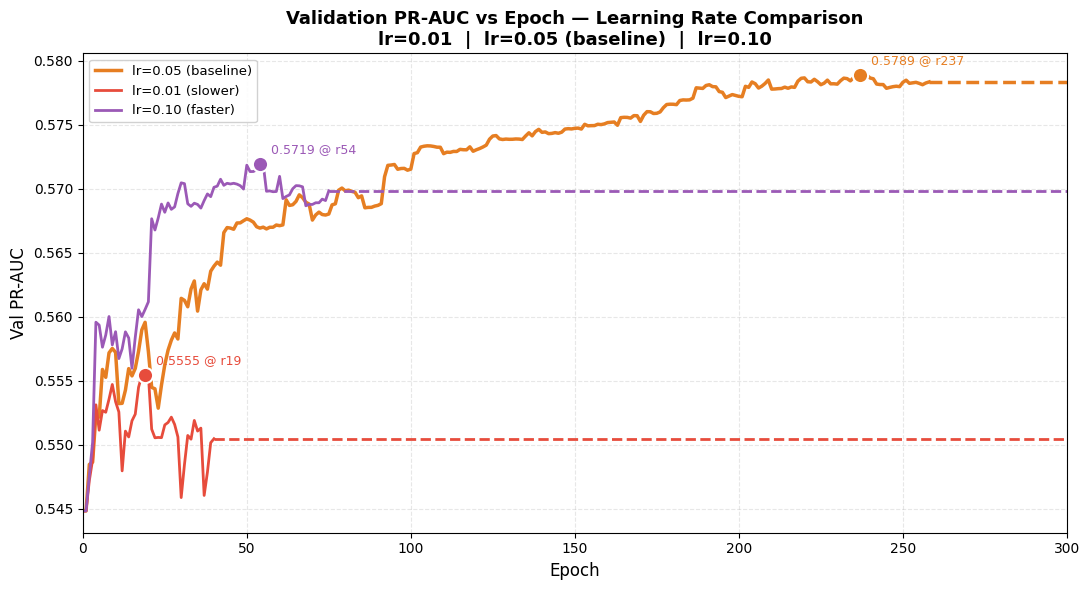

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for cfg in configs:
    color = cfg['color']
    lw    = cfg['lw']

    # prepend 0 so line starts from x=0
    r_real_full = [0] + cfg['r_real']
    v_real_full = [cfg['v_real'][0]] + cfg['v_real']

    r_dash = [cfg['r_real'][-1]] + cfg['r_ext']
    v_dash = [cfg['v_real'][-1]] + cfg['v_ext']

    # solid line — real training
    ax.plot(r_real_full, v_real_full,
            color=color, linewidth=lw, linestyle='-',
            label=f"{cfg['label']}")

    # dashed line — flat extension to 300
    ax.plot(r_dash, v_dash,
            color=color, linewidth=lw,
            linestyle='--', alpha=1.0)

    # dot at best round — same style as fn_vs_threshold
    ax.scatter([cfg['best_r']], [cfg['best_auc']],
               color=color, s=120, zorder=6,
               edgecolors='white', linewidths=1.5)

    # annotation — same style as fn_vs_threshold
    ax.annotate(f"{cfg['best_auc']:.4f} @ r{cfg['best_r']}",
                xy=(cfg['best_r'], cfg['best_auc']),
                xytext=(8, 8), textcoords='offset points',
                fontsize=9, color=color)

ax.set_xticks(range(0, FULL_EPOCHS + 1, 50))
ax.set_xlim(0, FULL_EPOCHS)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Val PR-AUC', fontsize=12)
ax.set_title(
    'Validation PR-AUC vs Epoch — Learning Rate Comparison\n'
    'lr=0.01  |  lr=0.05 (baseline)  |  lr=0.10',
    fontsize=13, fontweight='bold')
ax.legend(fontsize=9.5, framealpha=0.9, loc='upper left')
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()

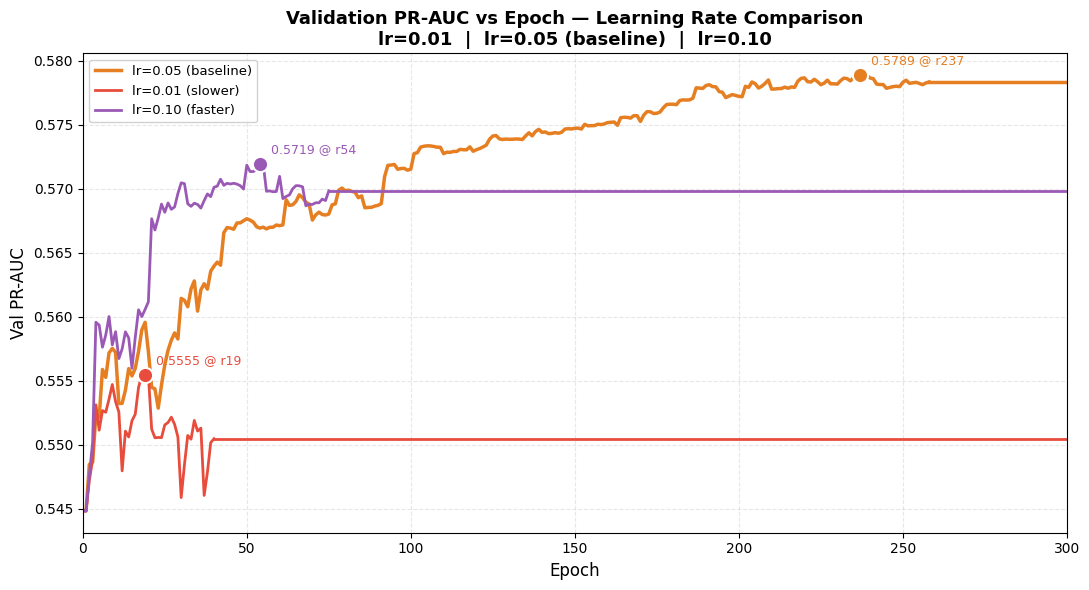

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for cfg in configs:
    color = cfg['color']
    lw    = cfg['lw']

    # prepend 0 so line starts from x=0
    r_real_full = [0] + cfg['r_real']
    v_real_full = [cfg['v_real'][0]] + cfg['v_real']

    r_dash = [cfg['r_real'][-1]] + cfg['r_ext']
    v_dash = [cfg['v_real'][-1]] + cfg['v_ext']

    # solid line — real training
    ax.plot(r_real_full, v_real_full,
            color=color, linewidth=lw, linestyle='-',
            label=f"{cfg['label']}")

    # straight line — extension to 300 (solid)
    ax.plot(r_dash, v_dash,
        color=color, linewidth=lw,
        linestyle='-', alpha=1.0)

    # dot at best round — same style as fn_vs_threshold
    ax.scatter([cfg['best_r']], [cfg['best_auc']],
               color=color, s=120, zorder=6,
               edgecolors='white', linewidths=1.5)

    # annotation — same style as fn_vs_threshold
    ax.annotate(f"{cfg['best_auc']:.4f} @ r{cfg['best_r']}",
                xy=(cfg['best_r'], cfg['best_auc']),
                xytext=(8, 8), textcoords='offset points',
                fontsize=9, color=color)

ax.set_xticks(range(0, FULL_EPOCHS + 1, 50))
ax.set_xlim(0, FULL_EPOCHS)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Val PR-AUC', fontsize=12)
ax.set_title(
    'Validation PR-AUC vs Epoch — Learning Rate Comparison\n'
    'lr=0.01  |  lr=0.05 (baseline)  |  lr=0.10',
    fontsize=13, fontweight='bold')
ax.legend(fontsize=9.5, framealpha=0.9, loc='upper left')
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()

In [ ]:
!pip install XlsxWriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 4.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
)

# --------------------------------------------------
# Assumes these already exist in your notebook:
# r_list, fp_list, fn_list, prec_list, rec_list
# y_test_aligned, y_test_rule_v1, y_test_rule_v2, ensemble_test_prob
# --------------------------------------------------

named_scores = [
    ("Rule V1 (Baseline)", y_test_rule_v1),
    ("Rule V2 (Baseline)", y_test_rule_v2),
    ("LSTM + KG + Policy (Ours)", ensemble_test_prob),
]

file_path = "xgb_graphs_editable.xlsx"

# -----------------------------
# Epoch-based sheets
# -----------------------------
df_fp_fn = pd.DataFrame({
    "Epoch": r_list,
    "False Positives": fp_list,
    "False Negatives": fn_list
})

df_pr_epoch = pd.DataFrame({
    "Epoch": r_list,
    "Precision": prec_list,
    "Recall": rec_list
})

with pd.ExcelWriter(file_path, engine="xlsxwriter") as writer:
    workbook = writer.book

    # =========================================================
    # 1) FP_FN sheet
    # =========================================================
    df_fp_fn.to_excel(writer, sheet_name="FP_FN", index=False)
    ws1 = writer.sheets["FP_FN"]

    chart1 = workbook.add_chart({"type": "line"})
    chart1.add_series({
        "name":       ["FP_FN", 0, 1],
        "categories": ["FP_FN", 1, 0, len(df_fp_fn), 0],
        "values":     ["FP_FN", 1, 1, len(df_fp_fn), 1],
    })
    chart1.add_series({
        "name":       ["FP_FN", 0, 2],
        "categories": ["FP_FN", 1, 0, len(df_fp_fn), 0],
        "values":     ["FP_FN", 1, 2, len(df_fp_fn), 2],
    })
    chart1.set_title({"name": "FP & FN vs Epoch"})
    chart1.set_x_axis({"name": "Epoch"})
    chart1.set_y_axis({"name": "Count"})
    ws1.insert_chart("F2", chart1, {"x_scale": 1.5, "y_scale": 1.5})

    # =========================================================
    # 2) Precision_Recall sheet
    # =========================================================
    df_pr_epoch.to_excel(writer, sheet_name="Precision_Recall", index=False)
    ws2 = writer.sheets["Precision_Recall"]

    chart2 = workbook.add_chart({"type": "line"})
    chart2.add_series({
        "name":       ["Precision_Recall", 0, 1],
        "categories": ["Precision_Recall", 1, 0, len(df_pr_epoch), 0],
        "values":     ["Precision_Recall", 1, 1, len(df_pr_epoch), 1],
    })
    chart2.add_series({
        "name":       ["Precision_Recall", 0, 2],
        "categories": ["Precision_Recall", 1, 0, len(df_pr_epoch), 0],
        "values":     ["Precision_Recall", 1, 2, len(df_pr_epoch), 2],
    })
    chart2.set_title({"name": "Precision & Recall vs Epoch"})
    chart2.set_x_axis({"name": "Epoch"})
    chart2.set_y_axis({"name": "Score"})
    ws2.insert_chart("F2", chart2, {"x_scale": 1.5, "y_scale": 1.5})


    # Random baseline
    rand_col = len(named_scores) * 4
    rand_val = float(y_test_aligned.mean())

    ws3.write(0, rand_col, "Random Recall")
    ws3.write(0, rand_col + 1, "Random Precision")
    ws3.write_number(1, rand_col, 0.0)
    ws3.write_number(1, rand_col + 1, rand_val)
    ws3.write_number(2, rand_col, 1.0)
    ws3.write_number(2, rand_col + 1, rand_val)

    # smooth scatter chart with no dots
    pr_chart = workbook.add_chart({"type": "scatter", "subtype": "smooth"})
    pr_chart.set_title({"name": "Precision-Recall Curve"})
    pr_chart.set_x_axis({
        "name": "Recall",
        "min": 0,
        "max": 1,
        "major_unit": 0.2,
    })
    pr_chart.set_y_axis({
        "name": "Precision",
        "min": 0,
        "max": 1,
        "major_unit": 0.2,
    })

    for s in pr_series_info:
        pr_chart.add_series({
            "name":       s["name"],
            "categories": ["PR_Curve", 1, s["x_col"], s["nrows"], s["x_col"]],
            "values":     ["PR_Curve", 1, s["y_col"], s["nrows"], s["y_col"]],
            "marker":     {"type": "none"},
            "line":       {"width": 2.25},
        })

    pr_chart.add_series({
        "name":       f"Random ({rand_val:.3f})",
        "categories": ["PR_Curve", 1, rand_col, 2, rand_col],
        "values":     ["PR_Curve", 1, rand_col + 1, 2, rand_col + 1],
        "marker":     {"type": "none"},
        "line":       {"dash_type": "dash", "width": 1.5},
    })

    pr_chart.set_legend({"position": "right"})
    pr_chart.set_size({"width": 1000, "height": 600})

    ws3.insert_chart("N2", pr_chart, {"x_scale": 1.8, "y_scale": 1.8})

print(f"Saved: {file_path}")

NameError: name 'ws3' is not defined

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

# ----------------------------------------
# Compute curve (IMPORTANT: fewer points)
# ----------------------------------------
def compute_fp_fn_curve(scores, y_true, n_points=100):
    scores = np.asarray(scores, dtype=float)
    y_true = np.asarray(y_true)

    thresholds = np.linspace(scores.min(), scores.max(), n_points)

    fp_c, fn_c = [], []

    for t in thresholds:
        pred = (scores >= t).astype(int)
        tn_, fp_, fn_, tp_ = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
        fp_c.append(int(fp_))
        fn_c.append(int(fn_))

    thr_norm = (thresholds - thresholds.min()) / (thresholds.max() - thresholds.min() + 1e-12)

    return thr_norm, fp_c, fn_c


# ----------------------------------------
# Generate data
# ----------------------------------------
thr, fp_v1, fn_v1 = compute_fp_fn_curve(y_test_rule_v1, y_test_aligned)
_,   fp_v2, fn_v2 = compute_fp_fn_curve(y_test_rule_v2, y_test_aligned)
_,   fp_lstm, fn_lstm = compute_fp_fn_curve(ensemble_test_prob, y_test_aligned)

df_fp = pd.DataFrame({
    "Threshold": thr,
    "Rule V1": fp_v1,
    "Rule V2": fp_v2,
    "LSTM + KG": fp_lstm
})

df_fn = pd.DataFrame({
    "Threshold": thr,
    "Rule V1": fn_v1,
    "Rule V2": fn_v2,
    "LSTM + KG": fn_lstm
})


# ----------------------------------------
# Write Excel with CLEAN chart
# ----------------------------------------
file_name = "fp_fn_final_clean.xlsx"

with pd.ExcelWriter(file_name, engine="xlsxwriter") as writer:

    df_fp.to_excel(writer, sheet_name="FP", index=False)
    df_fn.to_excel(writer, sheet_name="FN", index=False)

    workbook = writer.book
    ws_fp = writer.sheets["FP"]
    ws_fn = writer.sheets["FN"]

    # -------- FP Chart --------
    chart_fp = workbook.add_chart({
        "type": "scatter",
        "subtype": "smooth"
    })

    for col in range(1, 4):
        chart_fp.add_series({
            "name":       ["FP", 0, col],
            "categories": ["FP", 1, 0, len(df_fp), 0],
            "values":     ["FP", 1, col, len(df_fp), col],

            "marker": {"type": "none"},
            "line":   {"width": 2.5},
        })

    chart_fp.set_title({"name": "False Positives vs Threshold"})

    chart_fp.set_x_axis({
        "name": "Threshold",
        "min": 0,
        "max": 1,
        "major_unit": 0.2,
    })

    chart_fp.set_y_axis({
        "name": "FP Count",
    })

    chart_fp.set_legend({"position": "right"})
    chart_fp.set_size({"width": 1000, "height": 600})

    ws_fp.insert_chart("F2", chart_fp)

    # -------- FN Chart --------
    chart_fn = workbook.add_chart({
        "type": "scatter",
        "subtype": "smooth"
    })

    for col in range(1, 4):
        chart_fn.add_series({
            "name":       ["FN", 0, col],
            "categories": ["FN", 1, 0, len(df_fn), 0],
            "values":     ["FN", 1, col, len(df_fn), col],

            "marker": {"type": "none"},
            "line":   {"width": 2.5},
        })

    chart_fn.set_title({"name": "False Negatives vs Threshold"})

    chart_fn.set_x_axis({
        "name": "Threshold",
        "min": 0,
        "max": 1,
        "major_unit": 0.2,
    })

    chart_fn.set_y_axis({
        "name": "FN Count",
    })

    chart_fn.set_legend({"position": "right"})
    chart_fn.set_size({"width": 1000, "height": 600})

    ws_fn.insert_chart("F2", chart_fn)

print(f"Saved: {file_name}")

In [ ]:
# =========================================================
# COMPLETE UPDATED CODE
# - Saves PR-AUC vs Epoch chart to Excel
# - Saves Precision-Recall curve to Excel
# - Saves ROC curve to Excel
# - Uses smooth scatter lines with NO DOTS
# =========================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    roc_auc_score,
)

# -------------------------------------------------------------------
# REQUIRED INPUTS ALREADY EXPECTED IN YOUR NOTEBOOK
# -------------------------------------------------------------------
# 1) configs: list of dicts like:
# configs = [
#     {
#         "label": "lr=0.01",
#         "color": "#7F8C8D",
#         "lw": 2.0,
#         "r_real": [...],
#         "v_real": [...],
#         "r_ext": [...],
#         "v_ext": [...],
#         "best_r": 120,
#         "best_auc": 0.4567
#     },
#     ...
# ]
#
# 2) FULL_EPOCHS
#
# 3) named_scores:
# named_scores = [
#     ("Rule V1 (Baseline)", y_test_rule_v1),
#     ("Rule V2 (Baseline)", y_test_rule_v2),
#     ("LSTM + KG + Policy (Ours)", ensemble_test_prob),
# ]
#
# 4) y_test_aligned


# =========================================================
# BUILD PR-AUC VS EPOCH DATA
# =========================================================
epoch_data = {"Epoch": list(range(0, FULL_EPOCHS + 1))}

for cfg in configs:
    r_real_full = [0] + cfg["r_real"]
    v_real_full = [cfg["v_real"][0]] + cfg["v_real"]

    r_dash = [cfg["r_real"][-1]] + cfg["r_ext"]
    v_dash = [cfg["v_real"][-1]] + cfg["v_ext"]

    x_all = r_real_full + r_dash[1:]
    y_all = v_real_full + v_dash[1:]

    epoch_to_val = dict(zip(x_all, y_all))
    epoch_data[cfg["label"]] = [epoch_to_val.get(e, None) for e in range(0, FULL_EPOCHS + 1)]

df_epoch = pd.DataFrame(epoch_data)


# =========================================================
# WRITE EVERYTHING TO ONE EXCEL FILE
# =========================================================
file_name = "updated_pr_roc_epoch_curves.xlsx"

with pd.ExcelWriter(file_name, engine="xlsxwriter") as writer:
    workbook = writer.book

    # =========================================================
    # 1) Epoch_Curve sheet
    # =========================================================
    df_epoch.to_excel(writer, sheet_name="Epoch_Curve", index=False)
    ws1 = writer.sheets["Epoch_Curve"]

    epoch_chart = workbook.add_chart({"type": "scatter", "subtype": "smooth"})

    for col in range(1, len(df_epoch.columns)):
        epoch_chart.add_series({
            "name":       ["Epoch_Curve", 0, col],
            "categories": ["Epoch_Curve", 1, 0, len(df_epoch), 0],
            "values":     ["Epoch_Curve", 1, col, len(df_epoch), col],
            "marker":     {"type": "none"},
            "line":       {"width": 2.25},
        })

    epoch_chart.set_title({
        "name": "Validation PR-AUC vs Epoch — Learning Rate Comparison\nlr=0.01  |  lr=0.05 (baseline)  |  lr=0.10"
    })
    epoch_chart.set_x_axis({
        "name": "Epoch",
        "min": 0,
        "max": FULL_EPOCHS,
        "major_unit": 50,
    })
    epoch_chart.set_y_axis({
        "name": "Val PR-AUC",
    })
    epoch_chart.set_legend({"position": "top"})
    epoch_chart.set_size({"width": 1100, "height": 650})

    ws1.insert_chart("F2", epoch_chart)

    # =========================================================
    # 2) PR_Curve sheet
    # =========================================================
    ws3 = workbook.add_worksheet("PR_Curve")
    writer.sheets["PR_Curve"] = ws3

    pr_series_info = []

    for block_idx, (name, scores) in enumerate(named_scores):
        precision, recall, _ = precision_recall_curve(y_test_aligned, scores)
        ap = average_precision_score(y_test_aligned, scores)

        pr_df = pd.DataFrame({
            "Recall": recall,
            "Precision": precision
        }).sort_values("Recall").reset_index(drop=True)

        col = block_idx * 4
        ws3.write(0, col, f"{name} Recall")
        ws3.write(0, col + 1, f"{name} Precision")
        ws3.write(0, col + 2, "Model")
        ws3.write(0, col + 3, "AP")

        for i, (xv, yv) in enumerate(zip(pr_df["Recall"], pr_df["Precision"]), start=1):
            ws3.write_number(i, col, float(xv))
            ws3.write_number(i, col + 1, float(yv))

        ws3.write(1, col + 2, name)
        ws3.write_number(1, col + 3, float(ap))

        pr_series_info.append({
            "name": f"{name} (AP = {ap:.3f})",
            "x_col": col,
            "y_col": col + 1,
            "nrows": len(pr_df)
        })

    rand_col = len(named_scores) * 4
    rand_val = float(y_test_aligned.mean())

    ws3.write(0, rand_col, "Random Recall")
    ws3.write(0, rand_col + 1, "Random Precision")
    ws3.write_number(1, rand_col, 0.0)
    ws3.write_number(1, rand_col + 1, rand_val)
    ws3.write_number(2, rand_col, 1.0)
    ws3.write_number(2, rand_col + 1, rand_val)

    pr_chart = workbook.add_chart({"type": "scatter", "subtype": "smooth"})
    pr_chart.set_title({"name": "Precision-Recall Curve"})
    pr_chart.set_x_axis({
        "name": "Recall",
        "min": 0,
        "max": 1,
        "major_unit": 0.2,
    })
    pr_chart.set_y_axis({
        "name": "Precision",
        "min": 0,
        "max": 1,
        "major_unit": 0.2,
    })

    for s in pr_series_info:
        pr_chart.add_series({
            "name":       s["name"],
            "categories": ["PR_Curve", 1, s["x_col"], s["nrows"], s["x_col"]],
            "values":     ["PR_Curve", 1, s["y_col"], s["nrows"], s["y_col"]],
            "marker":     {"type": "none"},
            "line":       {"width": 2.25},
        })

    pr_chart.add_series({
        "name":       f"Random ({rand_val:.3f})",
        "categories": ["PR_Curve", 1, rand_col, 2, rand_col],
        "values":     ["PR_Curve", 1, rand_col + 1, 2, rand_col + 1],
        "marker":     {"type": "none"},
        "line":       {"dash_type": "dash", "width": 1.5},
    })

    pr_chart.set_legend({"position": "right"})
    pr_chart.set_size({"width": 1000, "height": 600})

    ws3.insert_chart("N2", pr_chart, {"x_scale": 1.8, "y_scale": 1.8})

    # =========================================================
    # 3) ROC_Curve sheet
    # =========================================================
    ws4 = workbook.add_worksheet("ROC_Curve")
    writer.sheets["ROC_Curve"] = ws4

    roc_series_info = []

    for block_idx, (name, scores) in enumerate(named_scores):
        fpr, tpr, _ = roc_curve(y_test_aligned, scores)
        auc_val = roc_auc_score(y_test_aligned, scores)

        roc_df = pd.DataFrame({
            "FPR": fpr,
            "TPR": tpr
        }).sort_values("FPR").reset_index(drop=True)

        col = block_idx * 4
        ws4.write(0, col, f"{name} FPR")
        ws4.write(0, col + 1, f"{name} TPR")
        ws4.write(0, col + 2, "Model")
        ws4.write(0, col + 3, "AUC")

        for i, (xv, yv) in enumerate(zip(roc_df["FPR"], roc_df["TPR"]), start=1):
            ws4.write_number(i, col, float(xv))
            ws4.write_number(i, col + 1, float(yv))

        ws4.write(1, col + 2, name)
        ws4.write_number(1, col + 3, float(auc_val))

        roc_series_info.append({
            "name": f"{name} (AUC = {auc_val:.3f})",
            "x_col": col,
            "y_col": col + 1,
            "nrows": len(roc_df)
        })

    diag_col = len(named_scores) * 4
    ws4.write(0, diag_col, "Random FPR")
    ws4.write(0, diag_col + 1, "Random TPR")
    ws4.write_number(1, diag_col, 0.0)
    ws4.write_number(1, diag_col + 1, 0.0)
    ws4.write_number(2, diag_col, 1.0)
    ws4.write_number(2, diag_col + 1, 1.0)

    roc_chart = workbook.add_chart({"type": "scatter", "subtype": "smooth"})
    roc_chart.set_title({"name": "ROC Curve"})
    roc_chart.set_x_axis({
        "name": "False Positive Rate",
        "min": 0,
        "max": 1,
        "major_unit": 0.2,
    })
    roc_chart.set_y_axis({
        "name": "True Positive Rate (Recall)",
        "min": 0,
        "max": 1,
        "major_unit": 0.2,
    })

    for s in roc_series_info:
        roc_chart.add_series({
            "name":       s["name"],
            "categories": ["ROC_Curve", 1, s["x_col"], s["nrows"], s["x_col"]],
            "values":     ["ROC_Curve", 1, s["y_col"], s["nrows"], s["y_col"]],
            "marker":     {"type": "none"},
            "line":       {"width": 2.25},
        })

    roc_chart.add_series({
        "name":       "Random",
        "categories": ["ROC_Curve", 1, diag_col, 2, diag_col],
        "values":     ["ROC_Curve", 1, diag_col + 1, 2, diag_col + 1],
        "marker":     {"type": "none"},
        "line":       {"dash_type": "dash", "width": 1.5},
    })

    roc_chart.set_legend({"position": "right"})
    roc_chart.set_size({"width": 1000, "height": 600})

    ws4.insert_chart("N2", roc_chart, {"x_scale": 1.8, "y_scale": 1.8})

print(f"Saved: {file_name}")